<a href="https://colab.research.google.com/github/Rahulbaid0404/Crop-management-system-for-small-farms/blob/main/Crop_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###*AI-POWERED CROP MANAGEMENT  FOR SMALL FARMS PROJECT*

This project idea incorporates various Coding operations using python, data visualisation,predictive modelling and machine learning concepts and algorithms.

Datasets used in this code file are:
1. Crop_recommendation.csv


In [ ]:
# Imports and basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/crop recommendation dataset.csv")

In [ ]:
df.head(6)

,N,P,K,temperature,humidity,pH,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice


In [ ]:
df.tail(7)

,N,P,K,temperature,humidity,pH,rainfall,label
2193,116,38,34,23.292503,50.045570,6.020947,183.468585,coffee
2194,97,35,26,24.914610,53.741447,6.334610,166.254931,coffee
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   pH           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.describe()

,N,P,K,temperature,humidity,pH,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
df.shape

(2200, 8)

In [ ]:
df.size

17600

In [ ]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'pH', 'rainfall', 'label'], dtype='object')

##Data Preprocessing

In [ ]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
pH,0
rainfall,0
label,0


In [ ]:
df.isnull().any()

,0
N,False
P,False
K,False
temperature,False
humidity,False
pH,False
rainfall,False
label,False


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2195,False
2196,False
2197,False
2198,False


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)
display(df.duplicated().sum())

np.int64(0)

### Identify and Handle Outliers using IQR Method

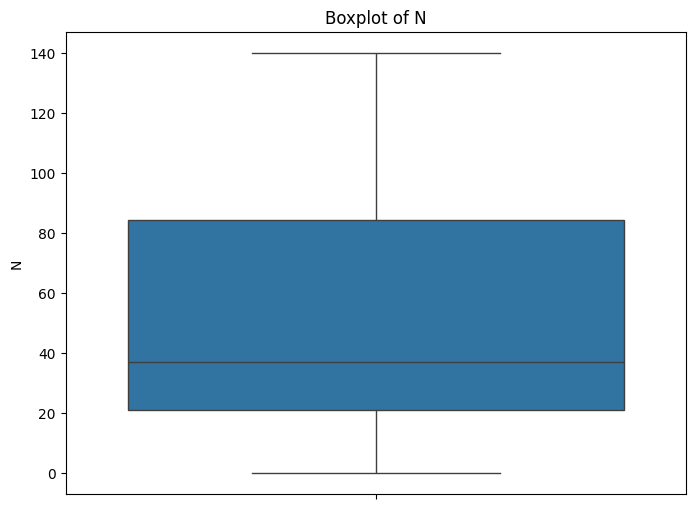

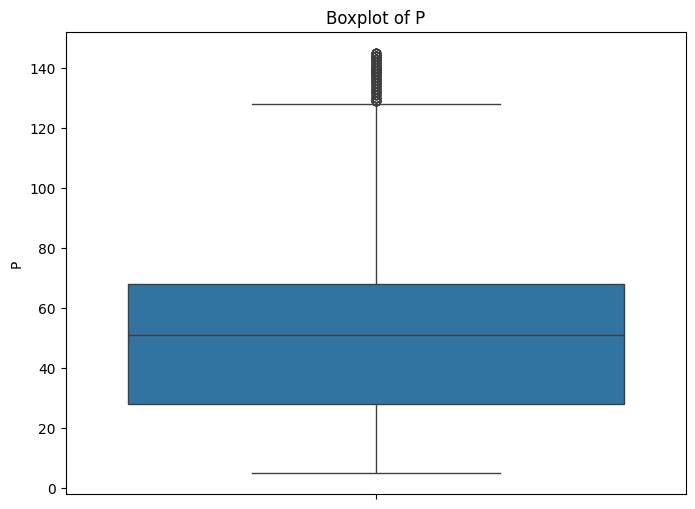

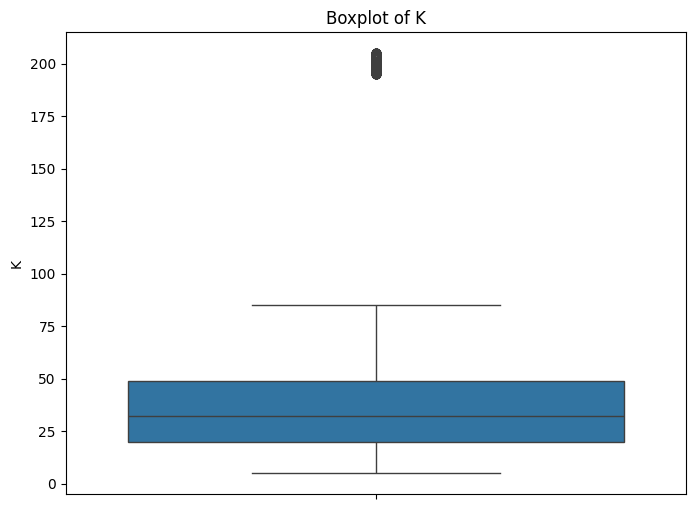

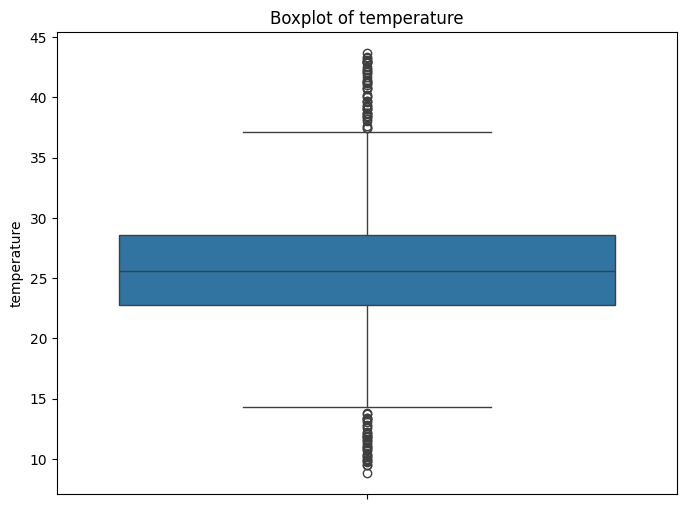

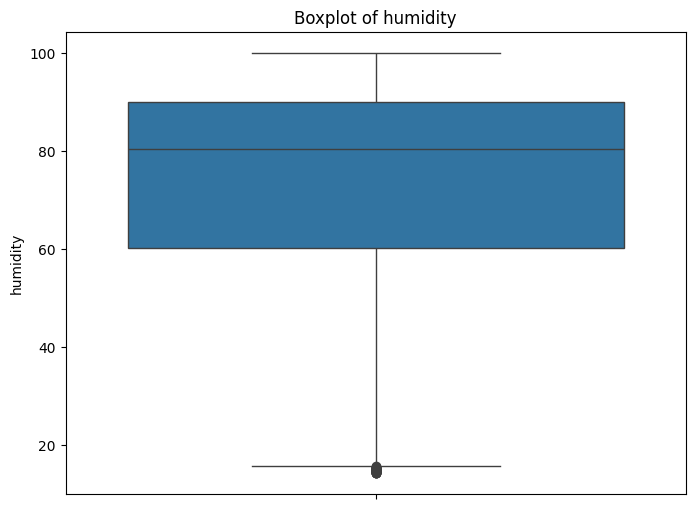

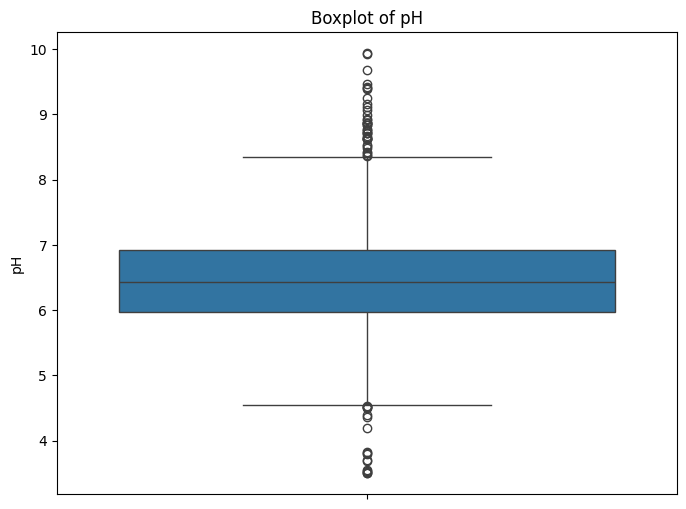

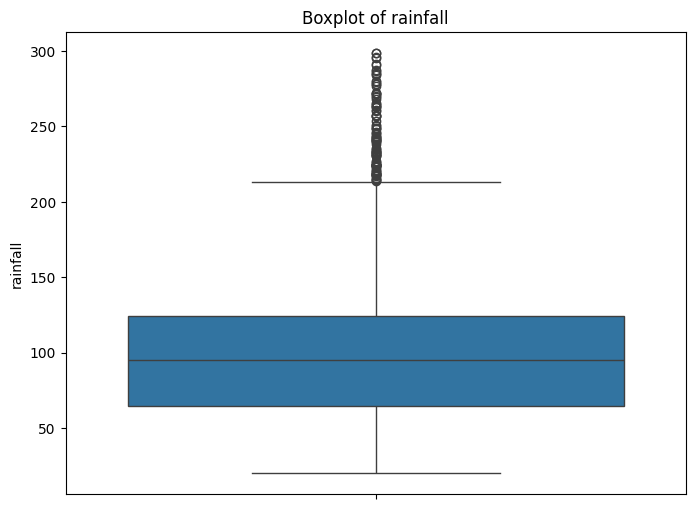

In [ ]:
#Boxplot Visualisation to find the outliers in each feature
import seaborn as sns

for column in df.columns:
  if df[column].dtype in ['int64', 'float64']:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, y=column)
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.show()

In [ ]:
import numpy as np

print("\n--- Identifying Outliers (before handling) ---")

# Loop through each numerical feature to identify outliers
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]

    print(f"\nFeature: {feature}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Store the original dataframe for comparison if needed
df_original = df.copy()

print("\n--- Handling Outliers (Capping) ---")
# Loop through each numerical feature to cap outliers
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping (Winsorization): replace outliers with the bounds
    df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
    df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])

    print(f"  Outliers in '{feature}' have been capped.")

print("\n--- Verification: Re-identifying Outliers (after handling) ---")
# Verify after capping
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_after = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    print(f"Feature: {feature}")
    print(f"  Number of outliers after capping: {len(outliers_after)}")

print("\nOutlier handling complete. Displaying box plots after capping:")


--- Identifying Outliers (before handling) ---

Feature: N
  Q1: 21.00, Q3: 84.25, IQR: 63.25
  Lower Bound: -73.88, Upper Bound: 179.12
  Number of outliers: 0 (0.00%)

Feature: P
  Q1: 28.00, Q3: 68.00, IQR: 40.00
  Lower Bound: -32.00, Upper Bound: 128.00
  Number of outliers: 138 (6.27%)

Feature: K
  Q1: 20.00, Q3: 49.00, IQR: 29.00
  Lower Bound: -23.50, Upper Bound: 92.50
  Number of outliers: 200 (9.09%)

Feature: temperature
  Q1: 22.77, Q3: 28.56, IQR: 5.79
  Lower Bound: 14.08, Upper Bound: 37.25
  Number of outliers: 86 (3.91%)

Feature: humidity
  Q1: 60.26, Q3: 89.95, IQR: 29.69
  Lower Bound: 15.73, Upper Bound: 134.48
  Number of outliers: 30 (1.36%)

Feature: pH
  Q1: 5.97, Q3: 6.92, IQR: 0.95
  Lower Bound: 4.54, Upper Bound: 8.35
  Number of outliers: 57 (2.59%)

Feature: rainfall
  Q1: 64.55, Q3: 124.27, IQR: 59.72
  Lower Bound: -25.02, Upper Bound: 213.84
  Number of outliers: 100 (4.55%)

--- Handling Outliers (Capping) ---
  Outliers in 'N' have been capped.
  

/tmp/ipykernel_850/1526091421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[feature], palette='viridis')
/tmp/ipykernel_850/1526091421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[feature], palette='viridis')
/tmp/ipykernel_850/1526091421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[feature], palette='viridis')
/tmp/ipykernel_850/1526091421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` fo

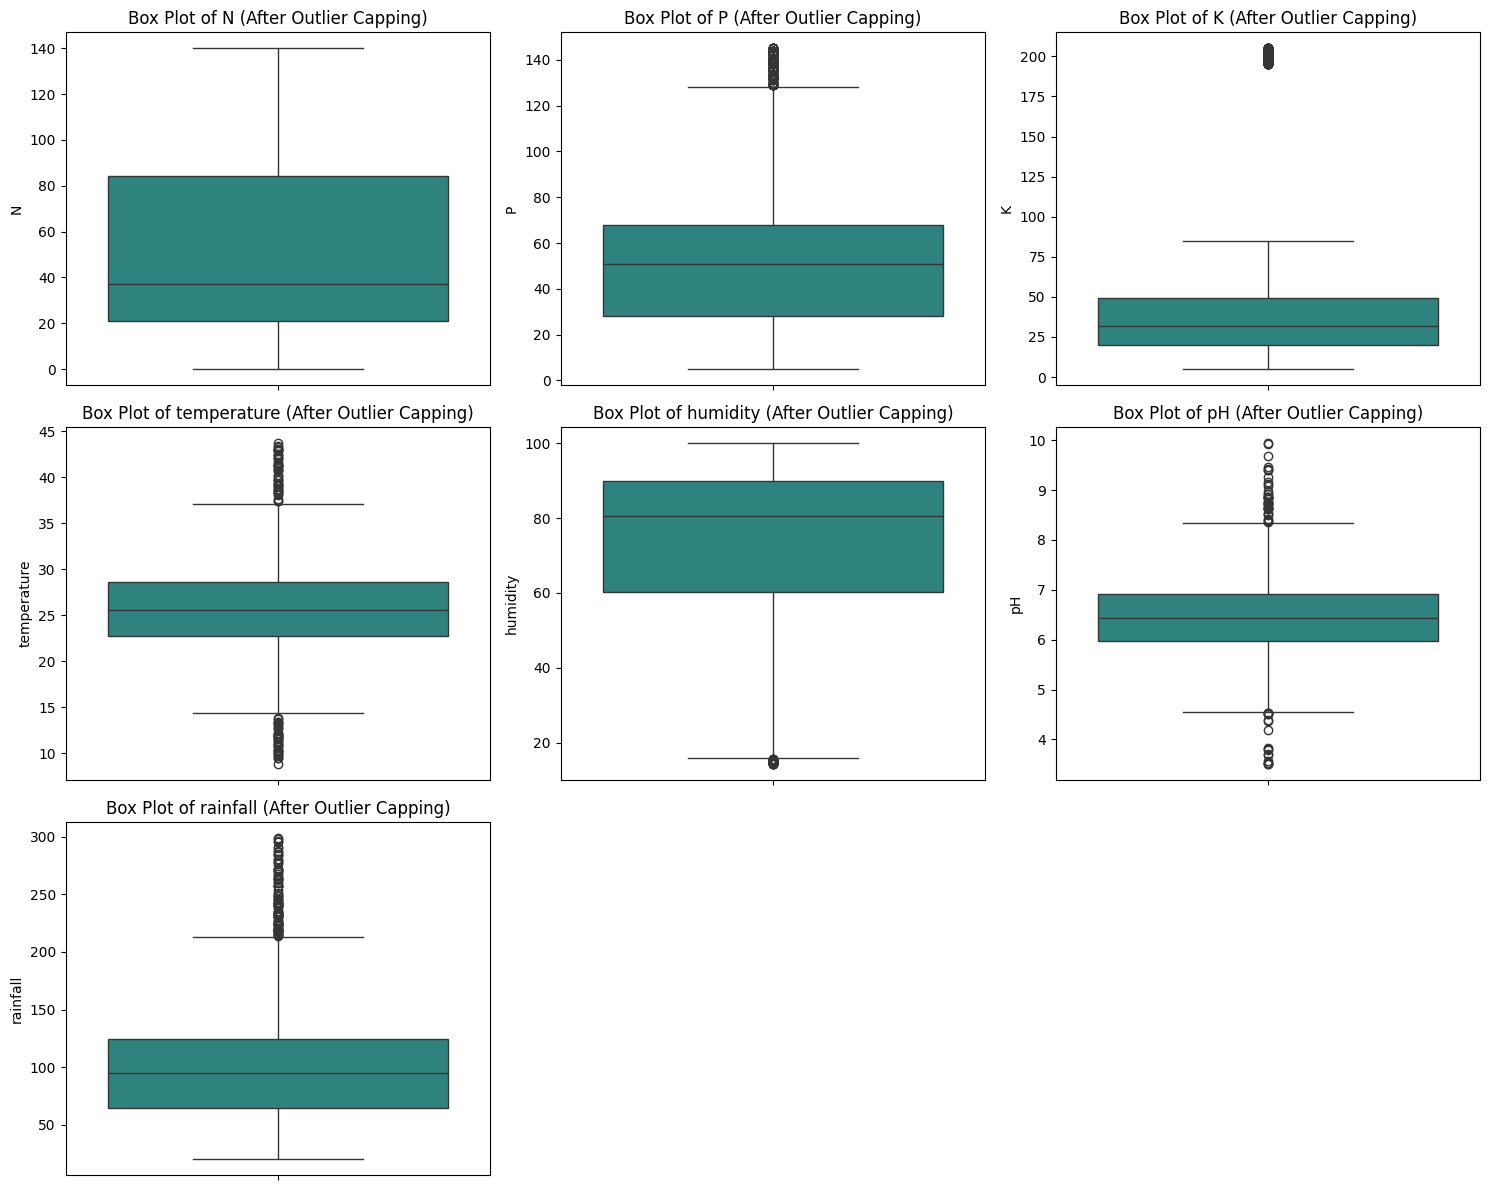

In [ ]:
# Visualize distributions after outlier handling (using box plots)
plt.figure(figsize=(15, 12))

for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.boxplot(y=df[feature], palette='viridis')
    plt.title(f'Box Plot of {feature} (After Outlier Capping)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

##Various Data Operations

In [ ]:
df.value_counts()

N      P     K     temperature  humidity   pH        rainfall    label        is_majority_crop
140.0  45.0  15.0  25.530827    80.046628  5.801048  99.395572   cotton       0                   1
0.0    5.0   36.0  24.351938    90.886124  6.152907  105.529185  pomegranate  0                   1
       12.0  7.0   20.184323    90.654585  6.969250  116.813097  orange       0                   1
       17.0  30.0  35.474783    47.972305  6.279134  97.790725   mango        0                   1
             42.0  23.202426    91.194427  6.859841  109.094632  pomegranate  0                   1
                                                                                                 ..
       29.0  32.0  28.059124    98.367098  5.868256  171.651640  coconut      0                   1
       27.0  38.0  22.445813    89.901470  6.738016  109.390600  pomegranate  0                   1
       26.0  31.0  25.070725    95.021568  5.547933  192.903631  coconut      0                   1
       25.0  14.0  19.335168    91.979789  6.361671  116.450422  orange       0                   1
       23.0  15.0  22.566642    93.374889  7.598729  109.858575  orange       0                   1
Name: count, Length: 2200, dtype: int64

In [21]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/crop recommendation dataset.csv")
rainfall = np.array(df['rainfall'])
print(rainfall)
print(rainfall.shape)
print(type(rainfall))

[202.9355362 226.6555374 263.9642476 ... 173.3228386 127.1752928
 140.9370415]
(2200,)
<class 'numpy.ndarray'>


In [22]:
label=np.array(df['label'])
print(label)
print(label.shape)
print(type(label))

['rice' 'rice' 'rice' ... 'coffee' 'coffee' 'coffee']
(2200,)
<class 'numpy.ndarray'>


In [23]:
temperature=np.array(df['temperature'])
print(temperature)
print(temperature.shape)
print(type(temperature))

[20.87974371 21.77046169 23.00445915 ... 24.13179691 26.2724184
 23.60301571]
(2200,)
<class 'numpy.ndarray'>


In [24]:
humidity=np.array(df['humidity'])
print(humidity)
print(humidity.shape)
print(type(humidity))

[82.00274423 80.31964408 82.3207629  ... 67.22512329 52.12739421
 60.39647474]
(2200,)
<class 'numpy.ndarray'>


In [25]:
pH=np.array(df['pH'])
print(pH)
print(pH.shape)
print(type(pH))

[6.50298529 7.03809636 7.84020714 ... 6.36260785 6.75879255 6.77983261]
(2200,)
<class 'numpy.ndarray'>


In [19]:
np.array('/content/crop recommendation dataset.csv')


array('/content/crop recommendation dataset.csv', dtype='<U40')

In [ ]:
# Perform one-hot encoding on the 'label' column
df_encoded = pd.get_dummies(df, columns=['label'], prefix='crop')

# Display the first 5 rows of the new encoded dataframe to verify the transformation
print("Original DataFrame:")
print(df.head())
print("\nDataFrame after One-Hot Encoding:")
print(df_encoded.head())

# Print the columns to show the new one-hot encoded columns
print("\nColumns of the encoded DataFrame:")
print(df_encoded.columns)

Original DataFrame:
      N     P     K  temperature   humidity        pH    rainfall label  \
0  90.0  42.0  43.0    20.879744  82.002744  6.502985  202.935536  rice   
1  85.0  58.0  41.0    21.770462  80.319644  7.038096  213.841241  rice   
2  60.0  55.0  44.0    23.004459  82.320763  7.840207  213.841241  rice   
3  74.0  35.0  40.0    26.491096  80.158363  6.980401  213.841241  rice   
4  78.0  42.0  42.0    20.130175  81.604873  7.628473  213.841241  rice   

   is_majority_crop  
0                 1  
1                 1  
2                 1  
3                 1  
4                 1  

DataFrame after One-Hot Encoding:
      N     P     K  temperature   humidity        pH    rainfall  \
0  90.0  42.0  43.0    20.879744  82.002744  6.502985  202.935536   
1  85.0  58.0  41.0    21.770462  80.319644  7.038096  213.841241   
2  60.0  55.0  44.0    23.004459  82.320763  7.840207  213.841241   
3  74.0  35.0  40.0    26.491096  80.158363  6.980401  213.841241   
4  78.0  42.0  42

In [ ]:
# Copy dataframe to avoid modifying original accidentally
data = df.copy()

# If column name typos exist (example: 'Temparature'), keep consistent naming
data = data.rename(columns=lambda x: x.strip())

# Identify features and target
target_col = 'Fertilizer Name'
categorical_cols = [c for c in data.columns if data[c].dtype == 'object' and c != target_col]
numeric_cols = [c for c in data.columns if data[c].dtype != 'object' and c != target_col]

print("Categorical cols:", categorical_cols)
print("Numeric cols:", numeric_cols)

Categorical cols: ['Soil Type', 'Crop Type']
Numeric cols: ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']


## **VISUALISING USING HEATMAP**

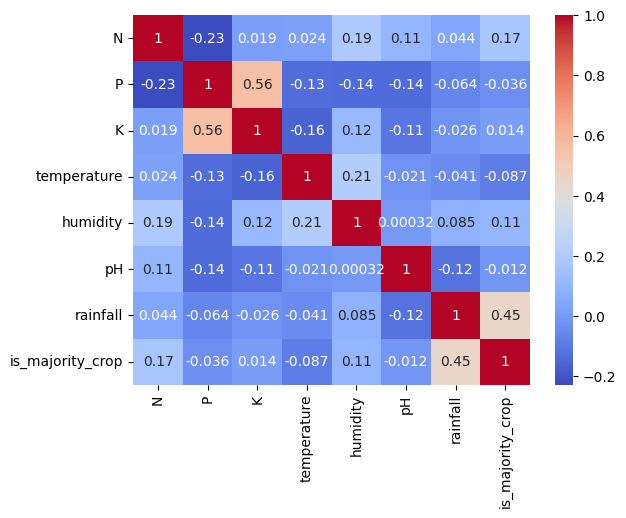

In [ ]:
#visualising using heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

### **VISUALISING USING HISTPLOT**

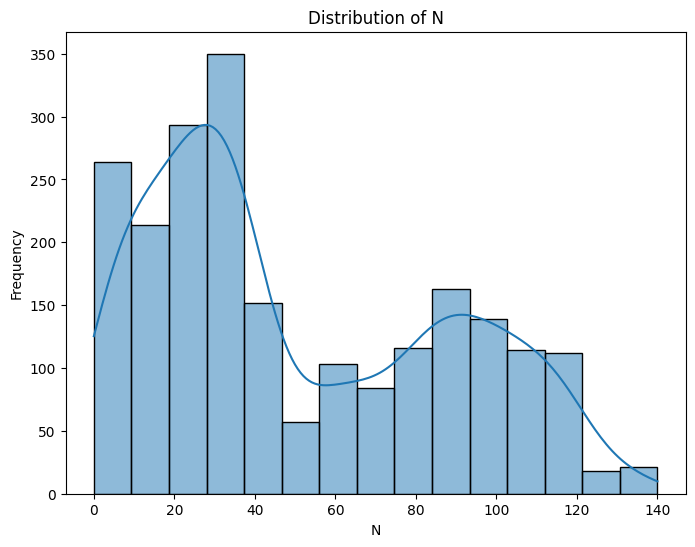

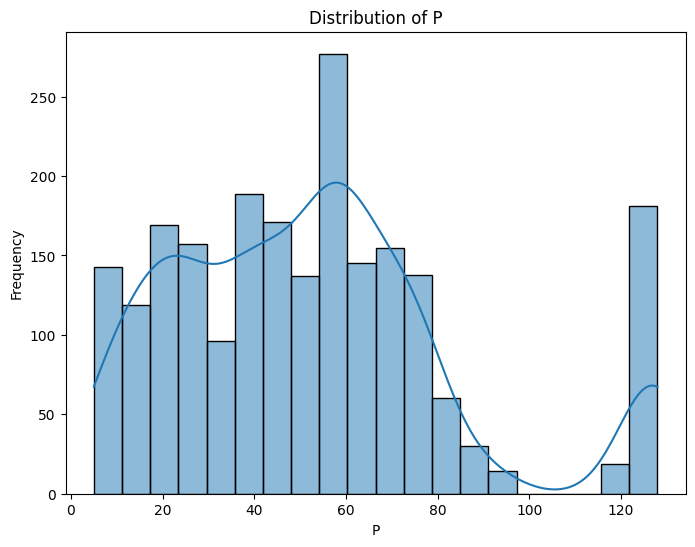

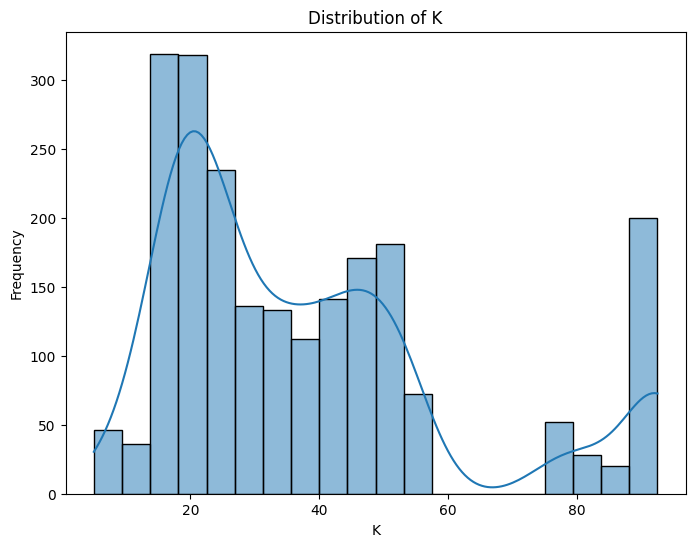

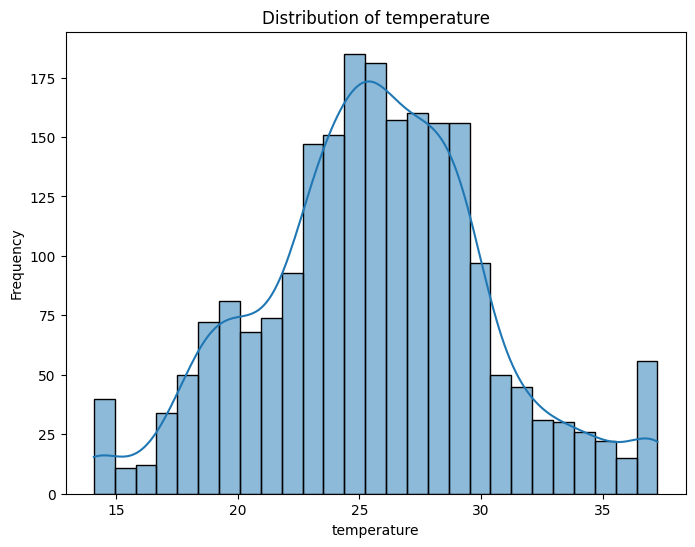

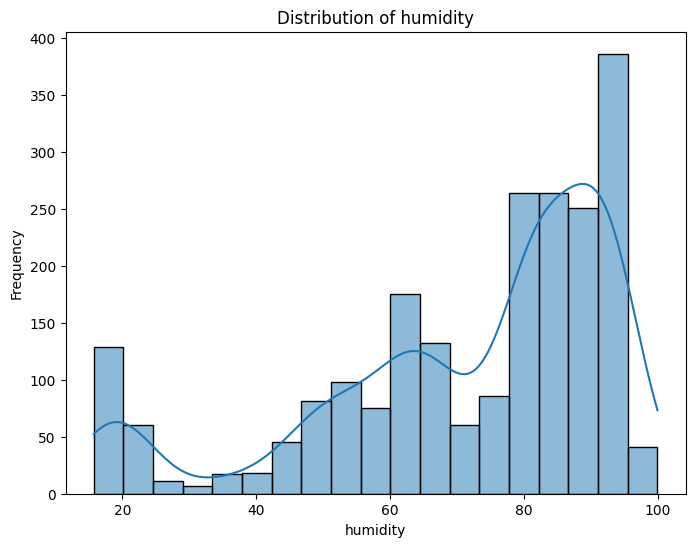

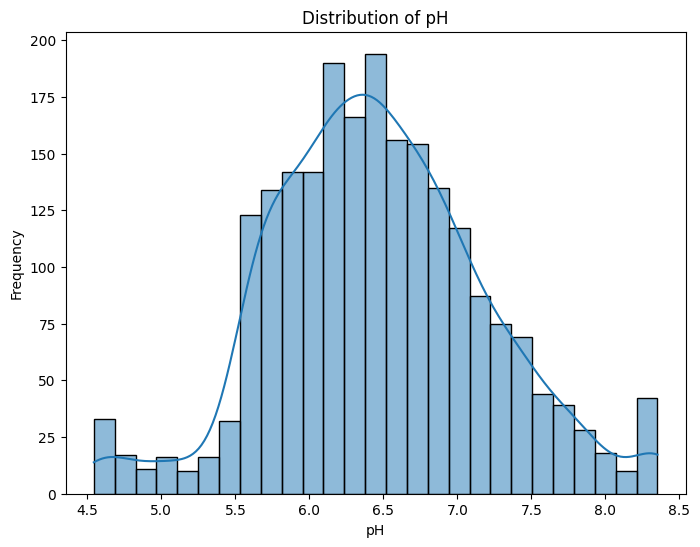

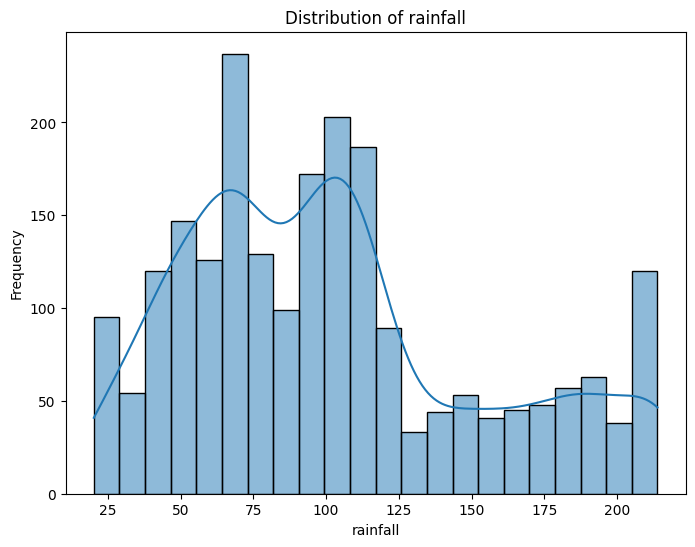

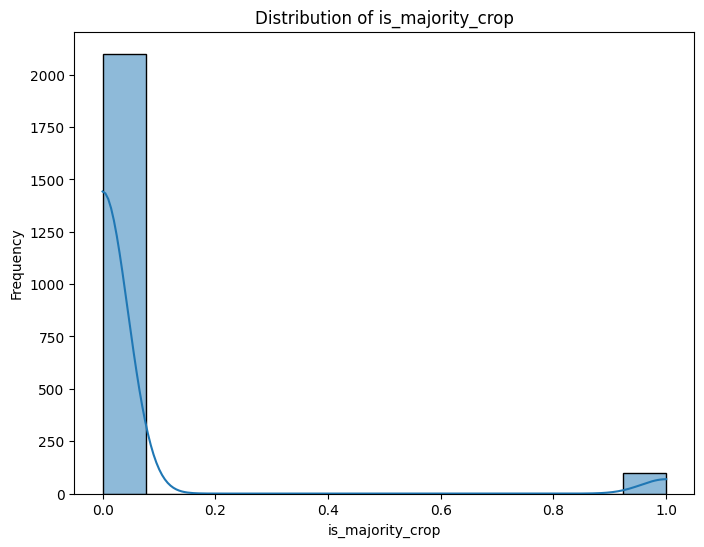

In [ ]:
for column in df.columns:
  if column != 'label':
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

### **VISUALISING WITH PAIR PLOT**

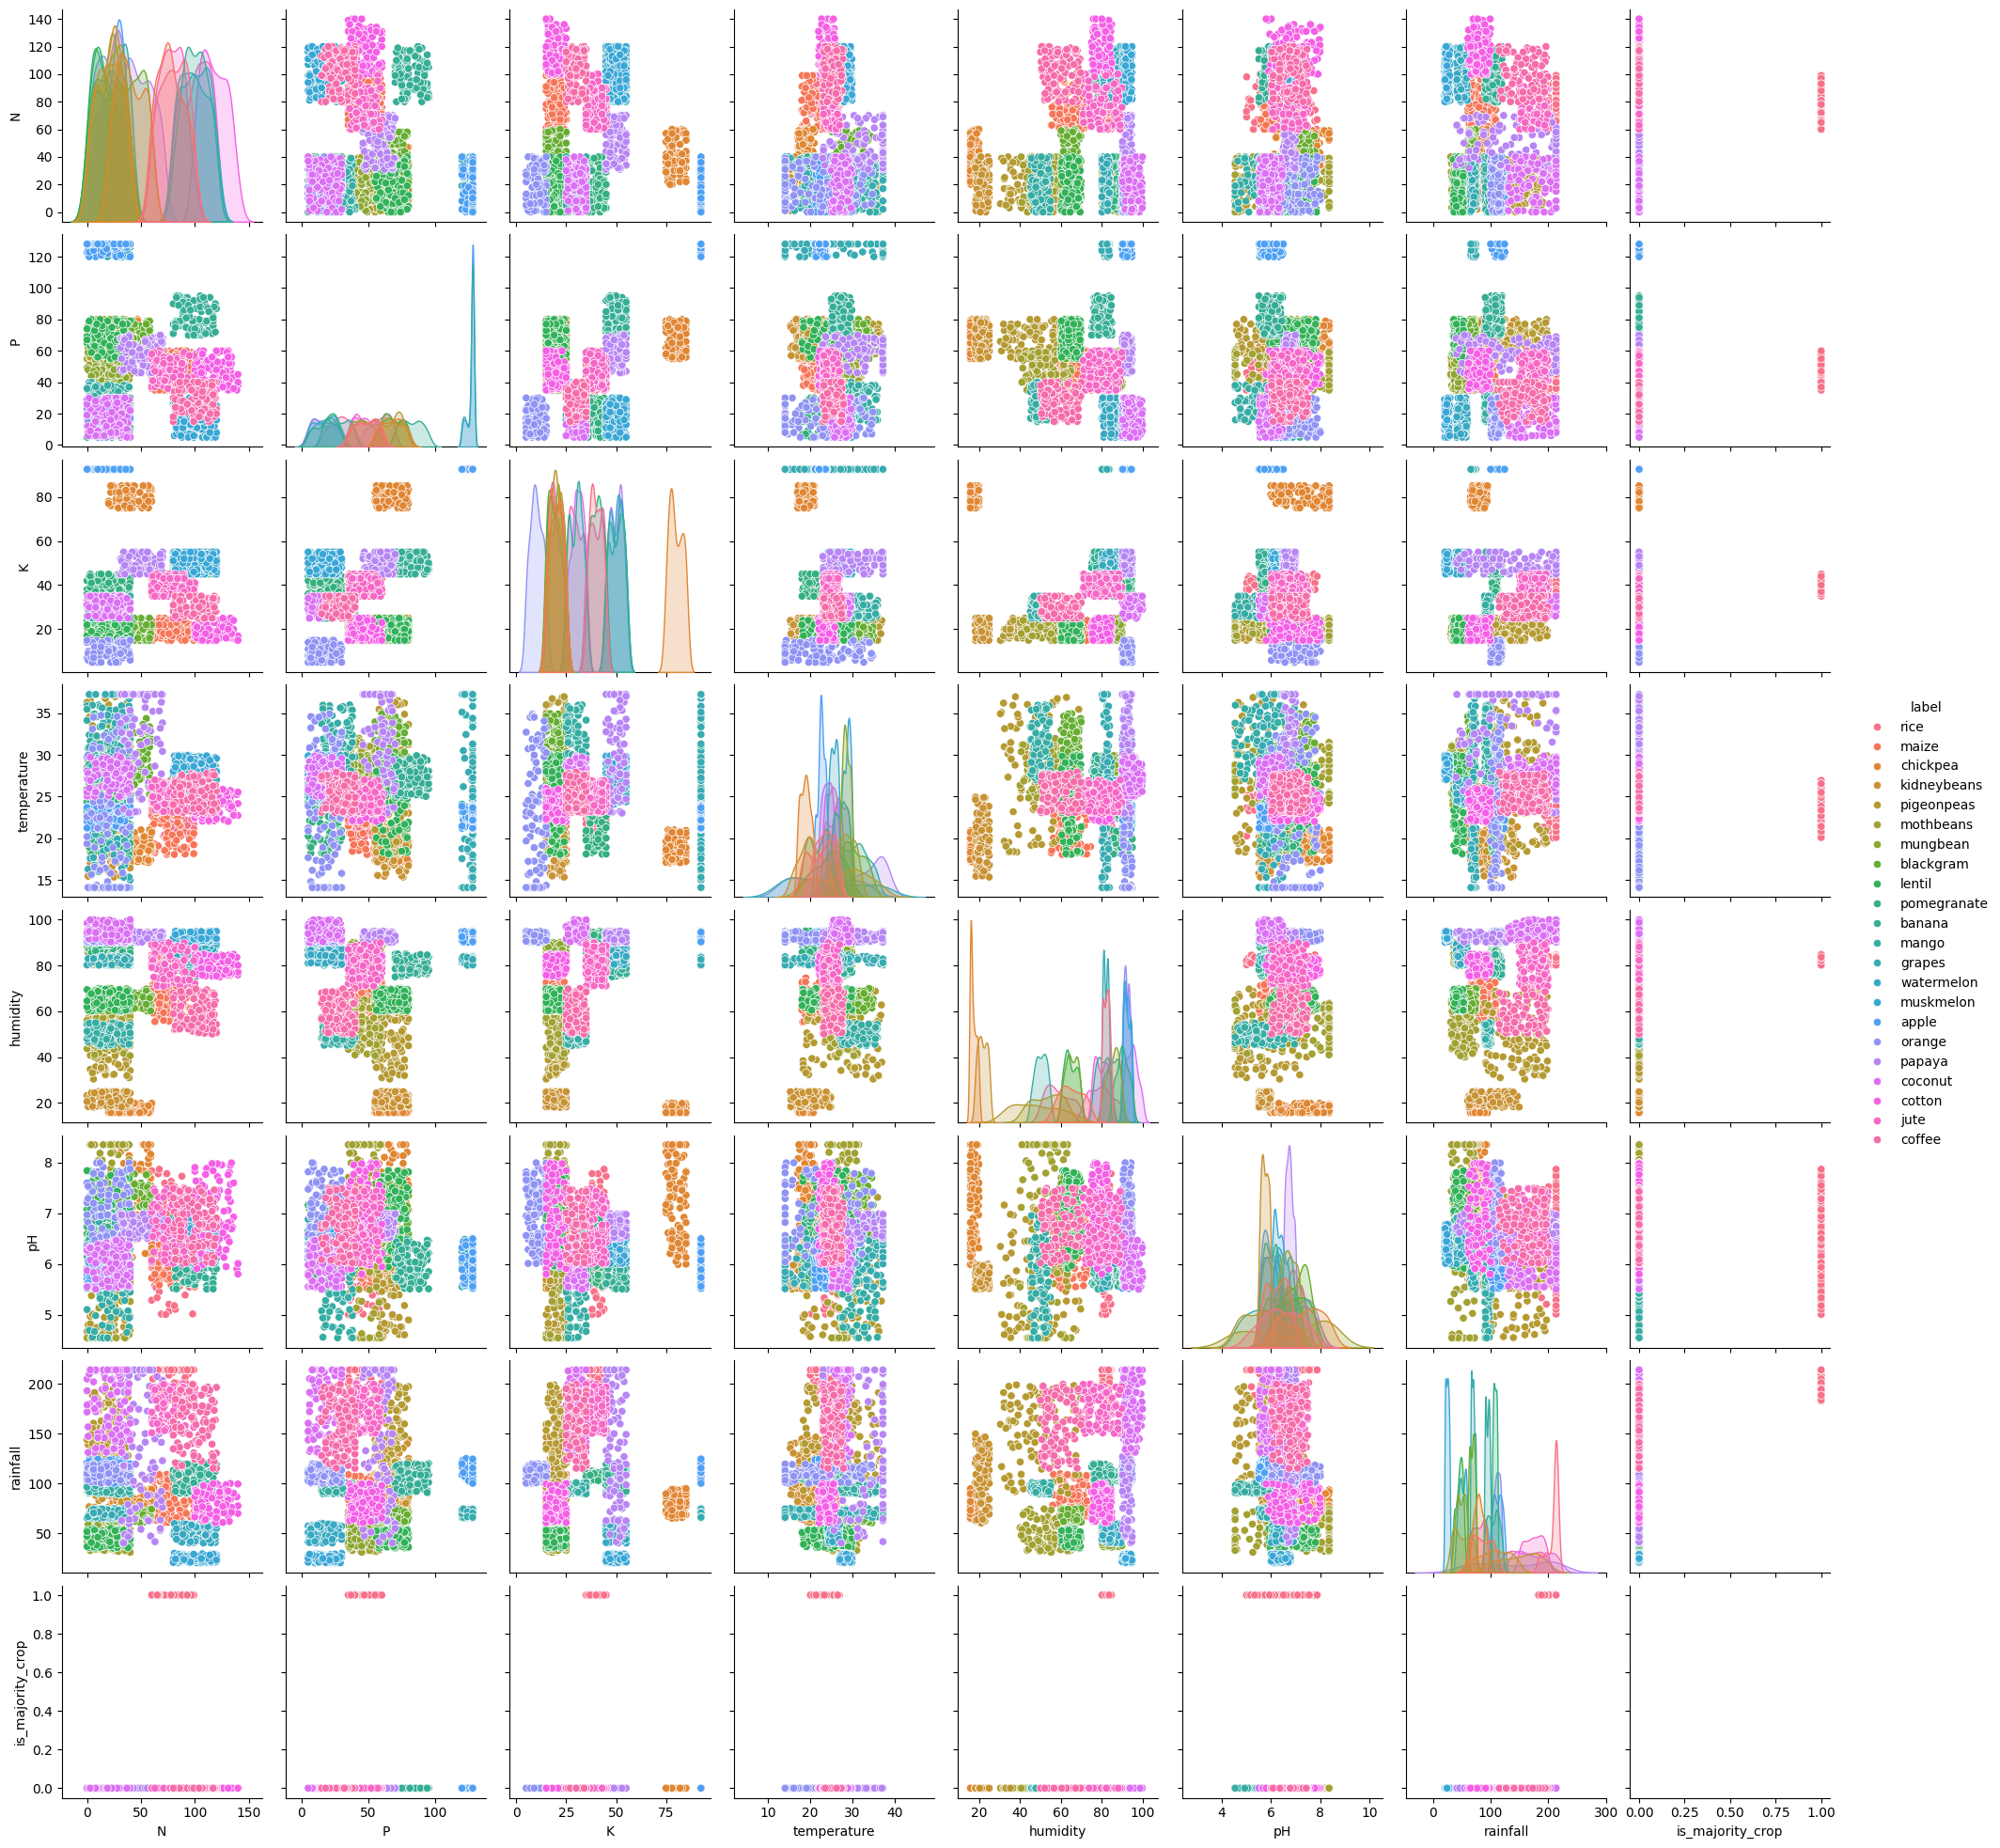

In [ ]:
sns.pairplot(df, hue='label')
plt.show()

### **VISUALISING WITH BAR PLOT**

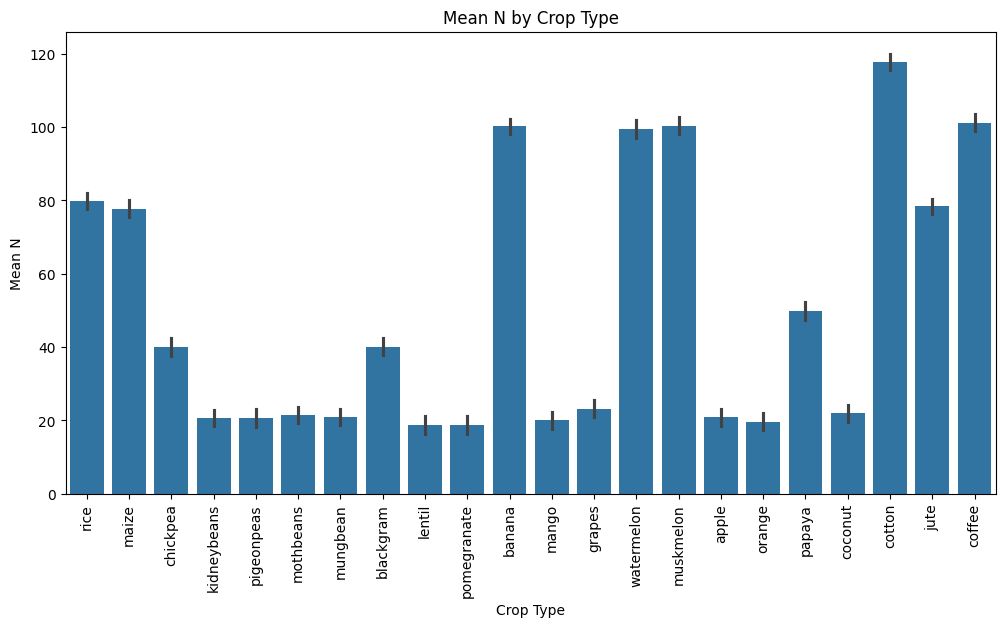

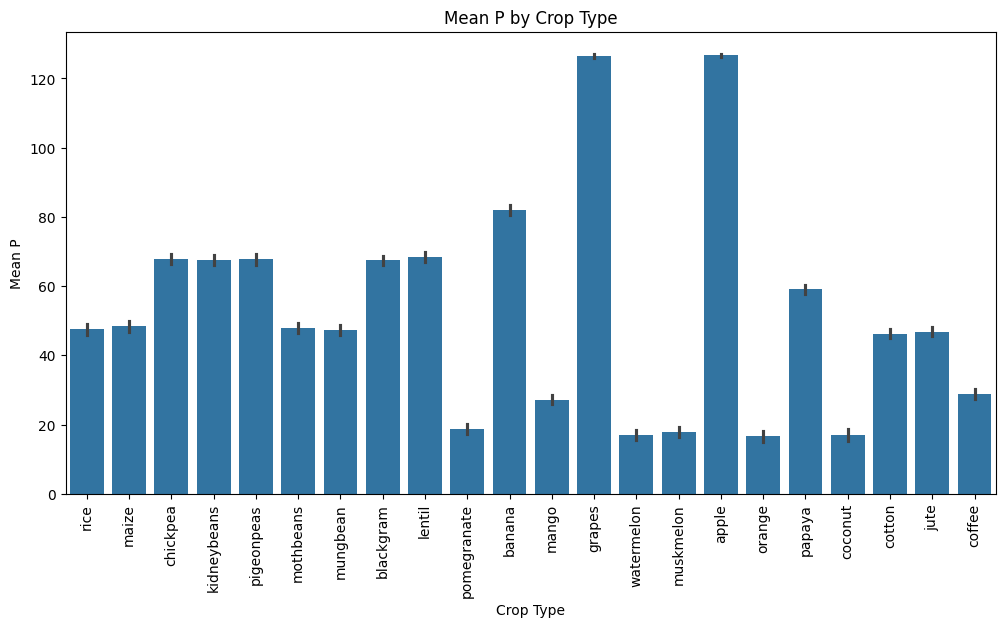

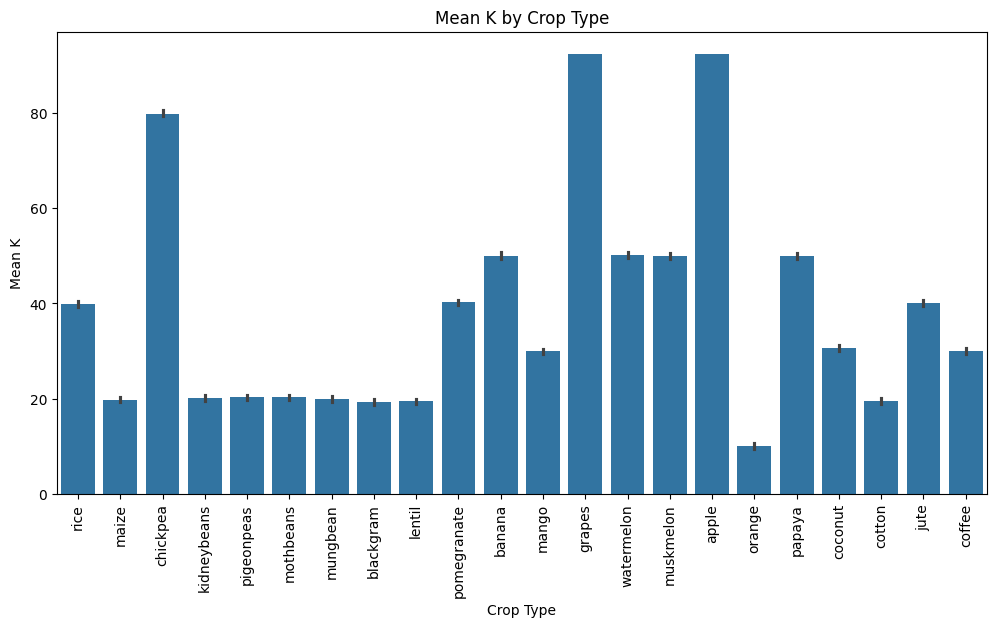

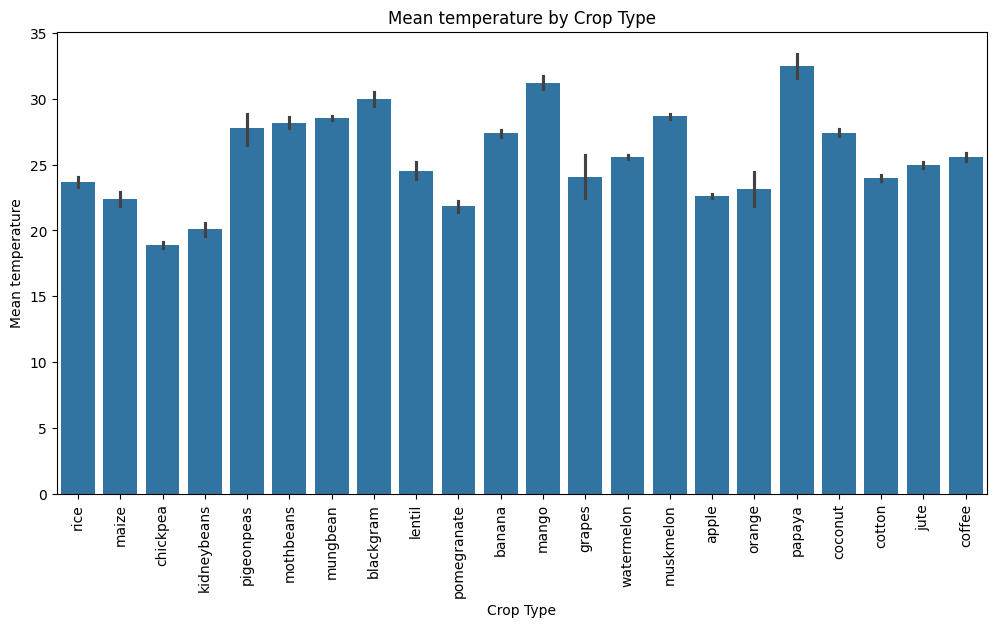

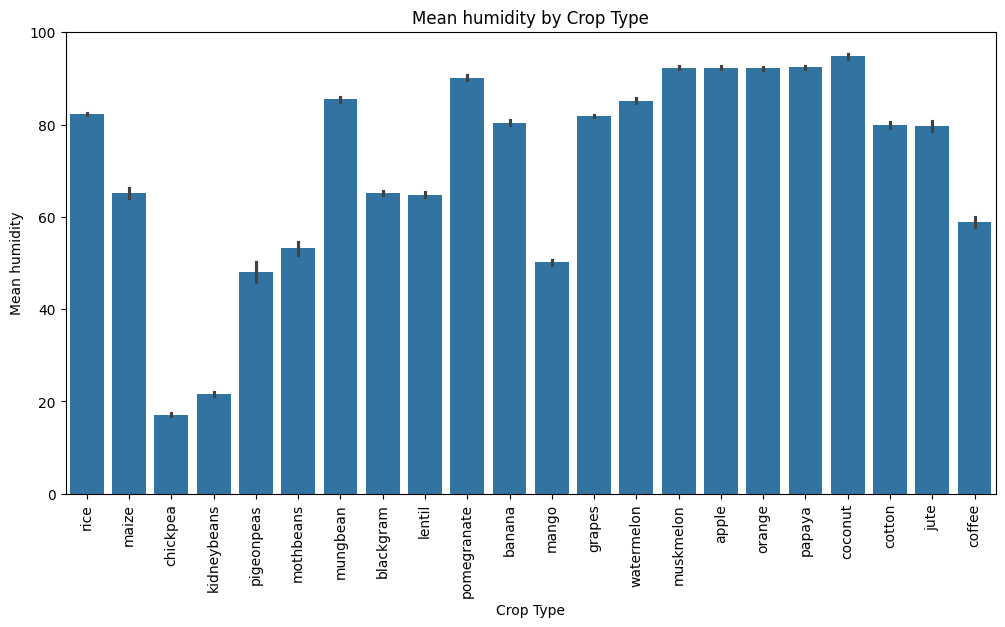

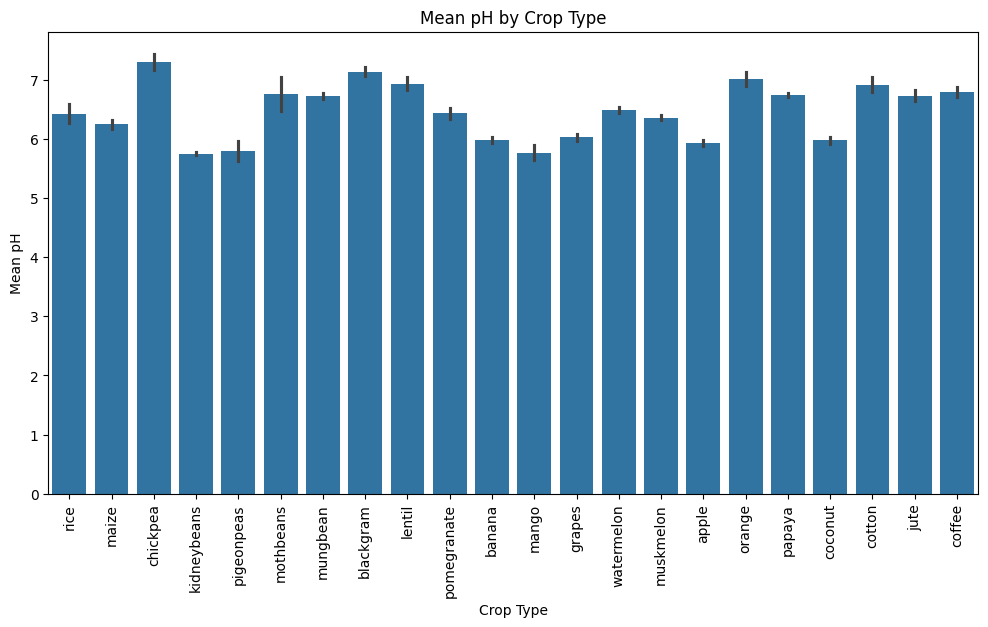

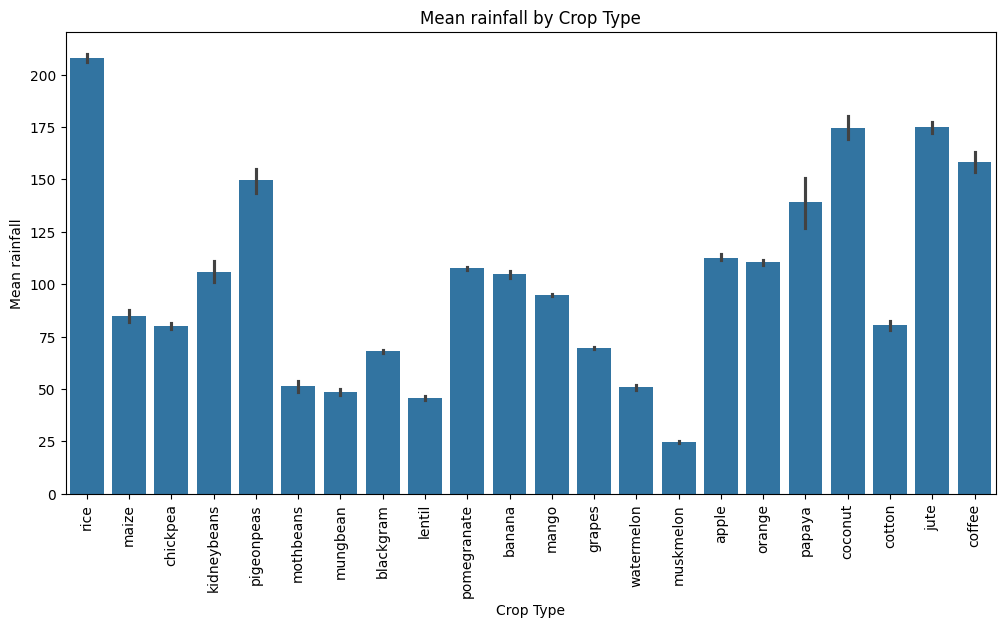

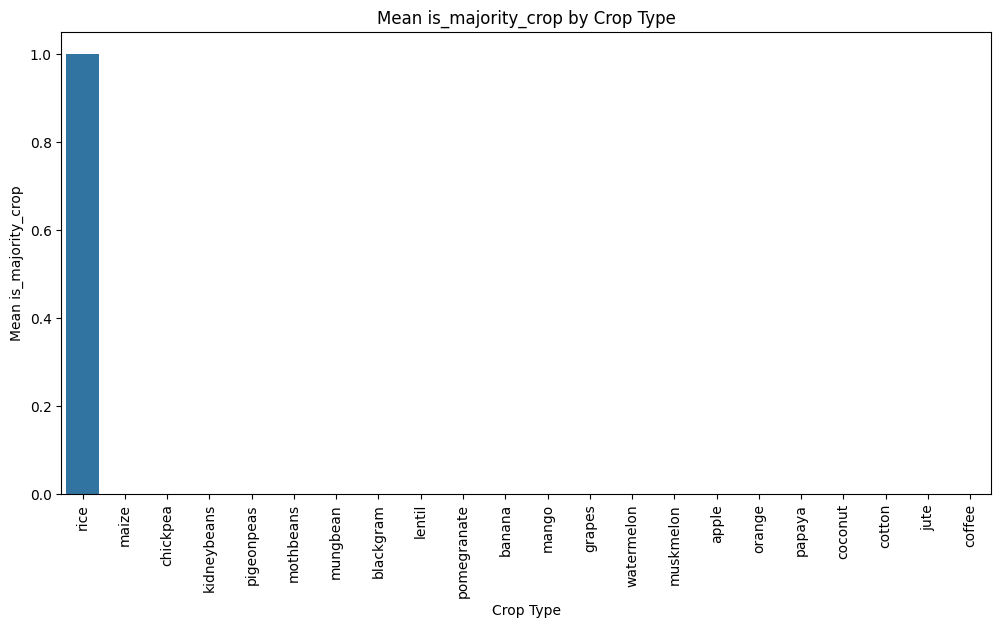

In [ ]:
for column in df.columns:
  if column != 'label':
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x='label', y=column)
    plt.title(f'Mean {column} by Crop Type')
    plt.xlabel('Crop Type')
    plt.ylabel(f'Mean {column}')
    plt.xticks(rotation=90)
    plt.show()

## **VISUALISING USING LINEPLOT**

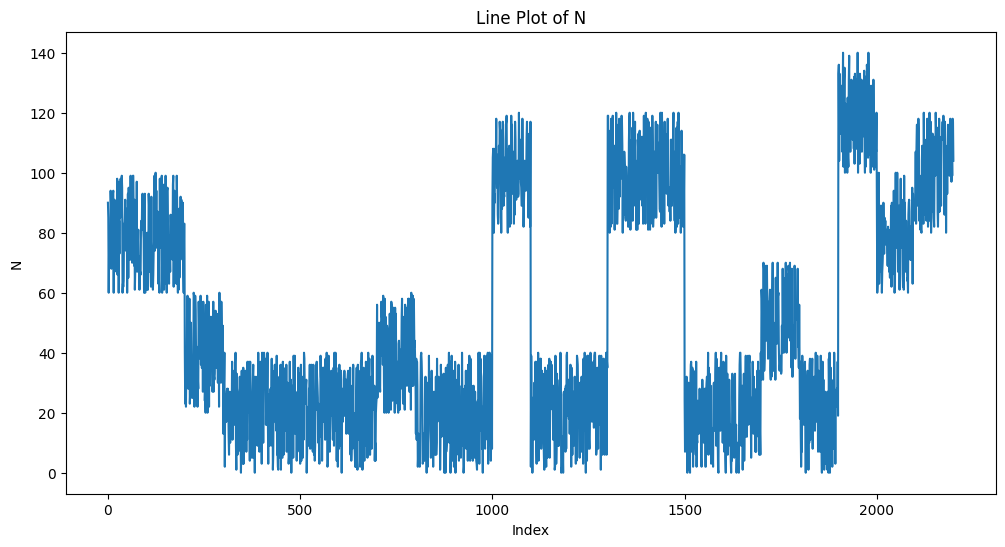

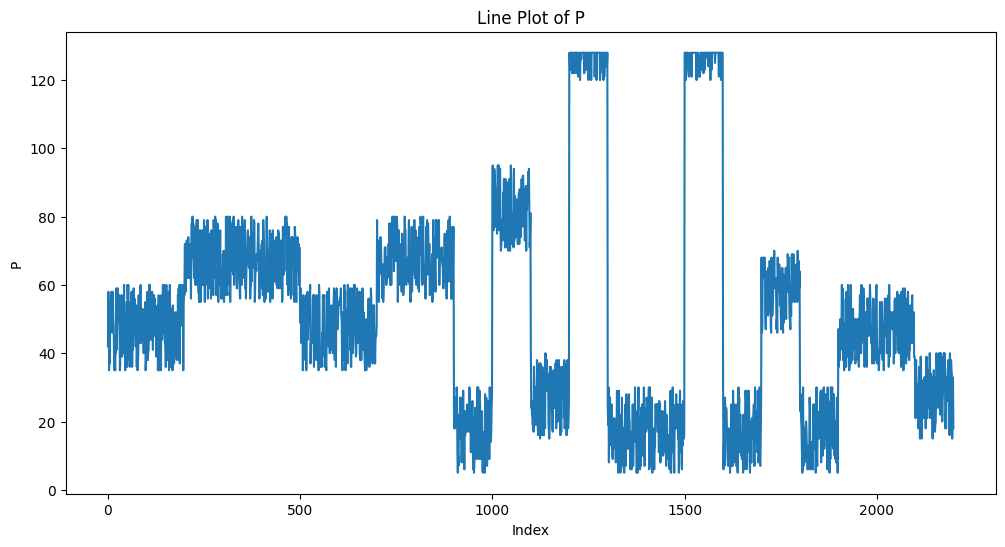

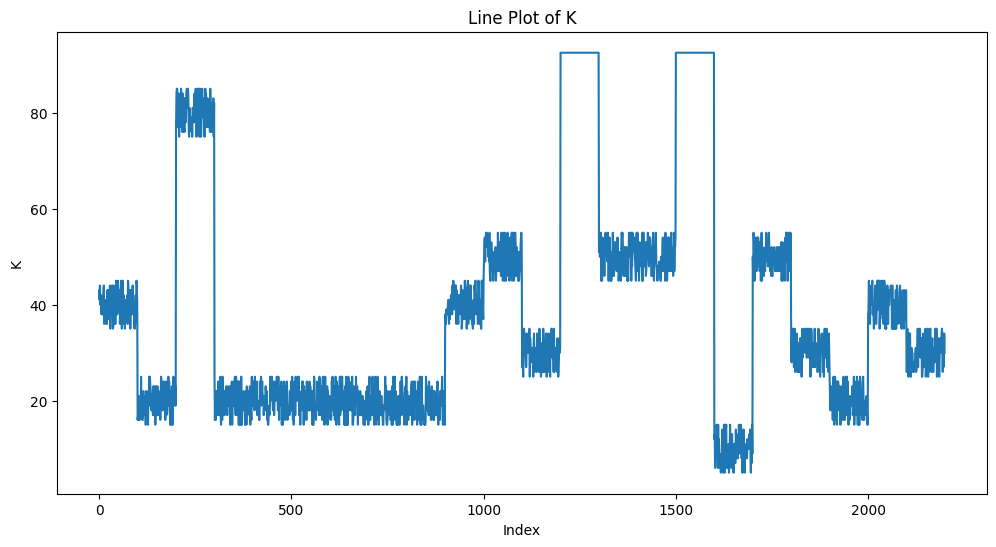

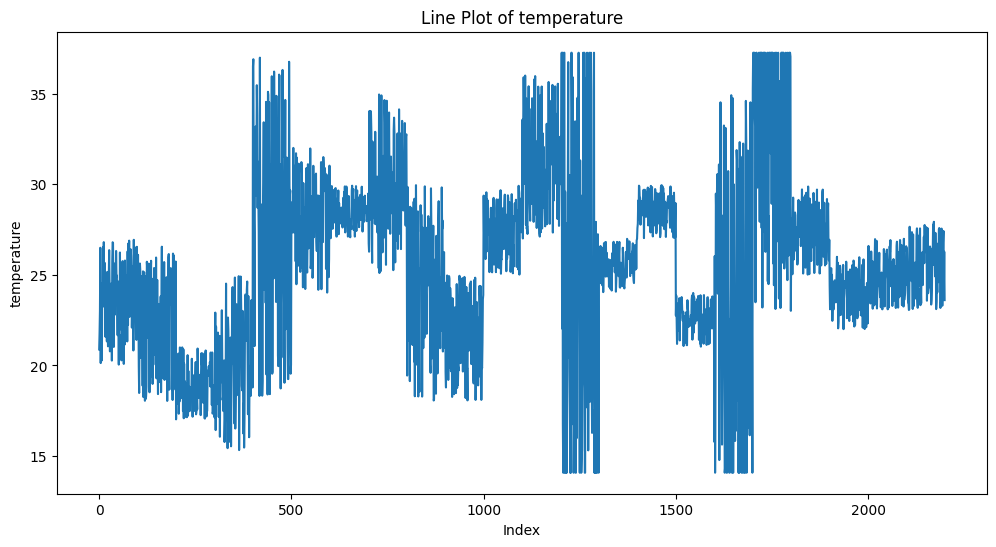

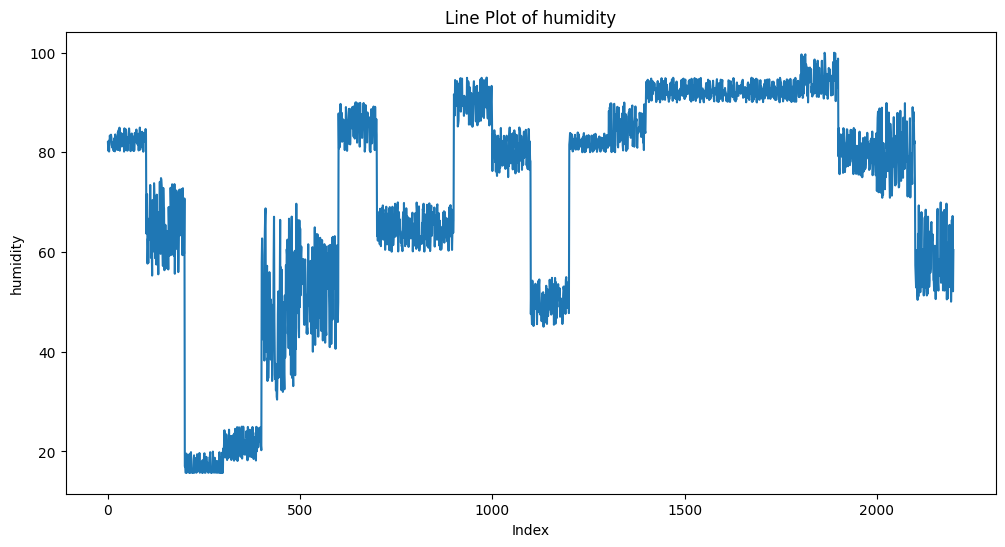

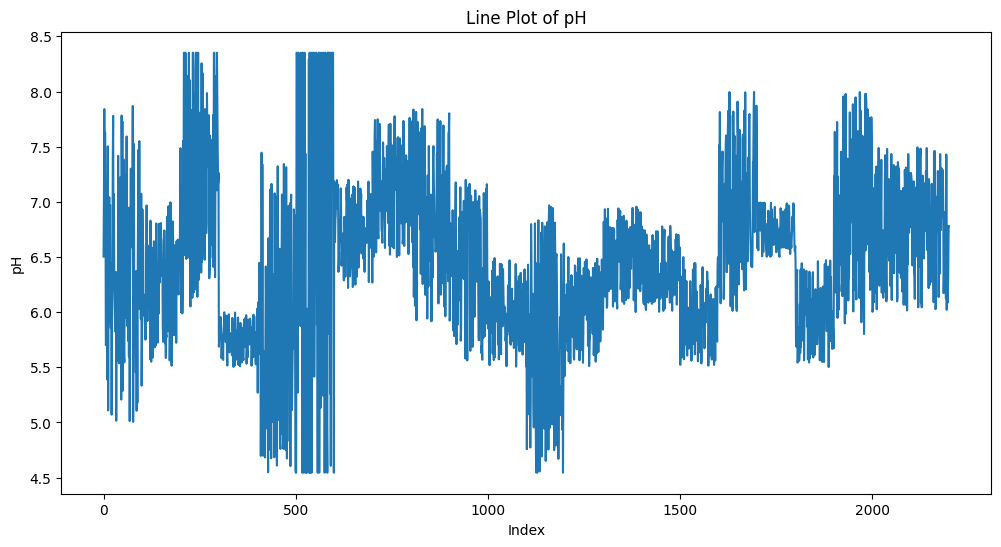

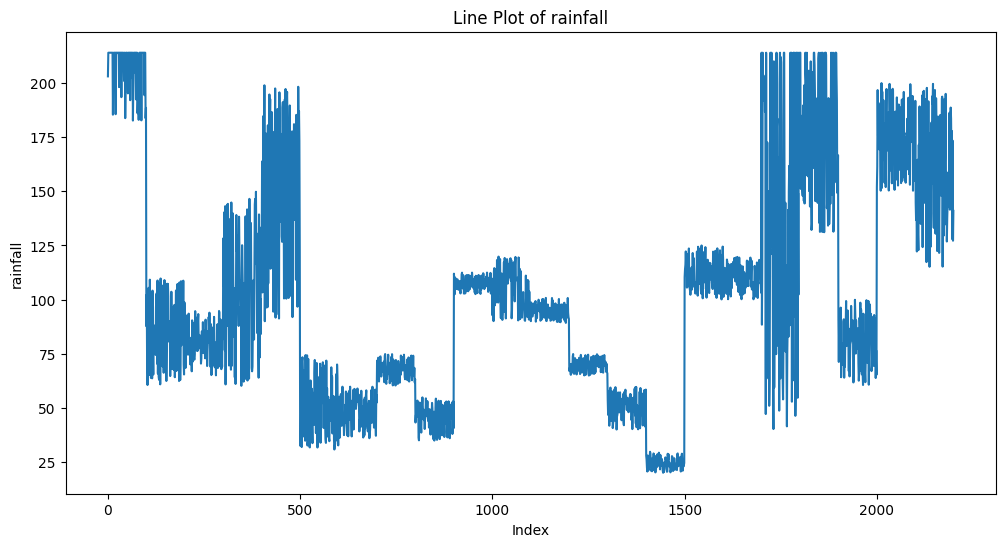

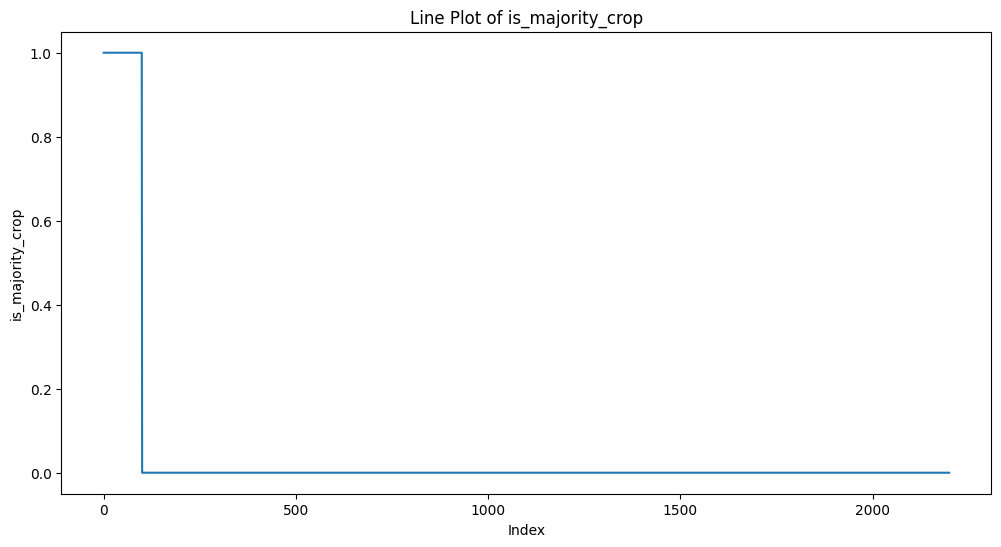

In [ ]:
for column in df.columns:
  if column != 'label':
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x=df.index, y=column)
    plt.title(f'Line Plot of {column}')
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.show()

#Visualising Using Word Clouds

In [ ]:
pip install wordcloud

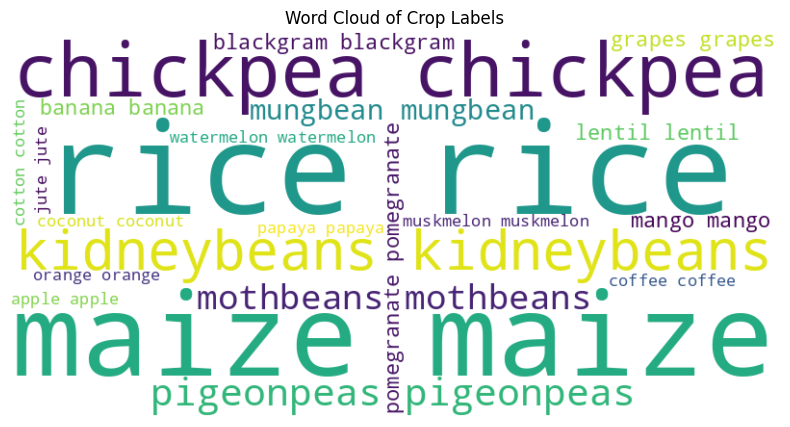

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all crop labels into a single string
text = ' '.join(df['label'])

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Crop Labels')
plt.show()

## Visualizing with boxplots






Generate boxplots for each column in the dataset to identify outliers and understand the distribution of each feature.


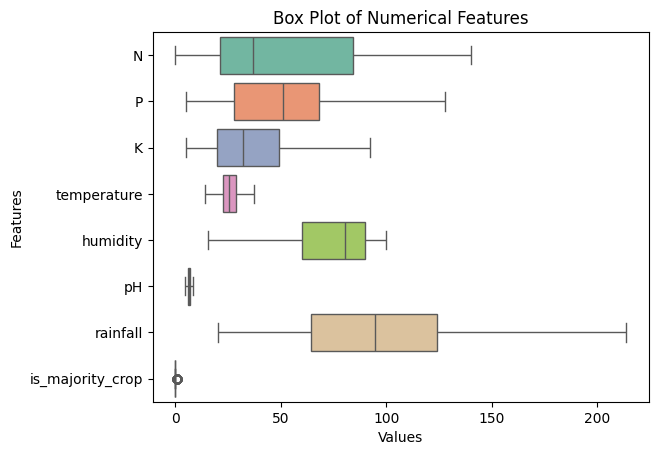

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df, orient="h", palette="Set2")
plt.title("Box Plot of Numerical Features")
plt.xlabel("Values")
plt.ylabel("Features")
plt.show()

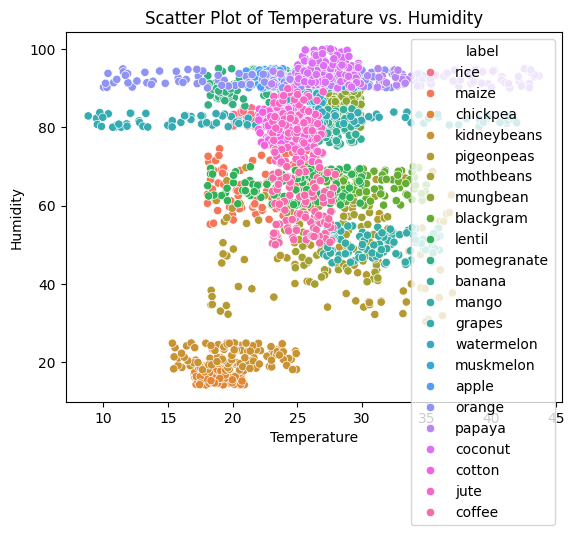

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x='temperature', y='humidity', hue='label')
plt.title("Scatter Plot of Temperature vs. Humidity")
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

##**Build an ML model Using Train-Test Split**

Select and train a machine learning model for crop recommendation based on the dataset features.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(classification_report(y_test, y_pred))

Accuracy: 0.9931818181818182
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        1

## Visualize Model Performance
Visualize the model's performance on both training and testing datasets.

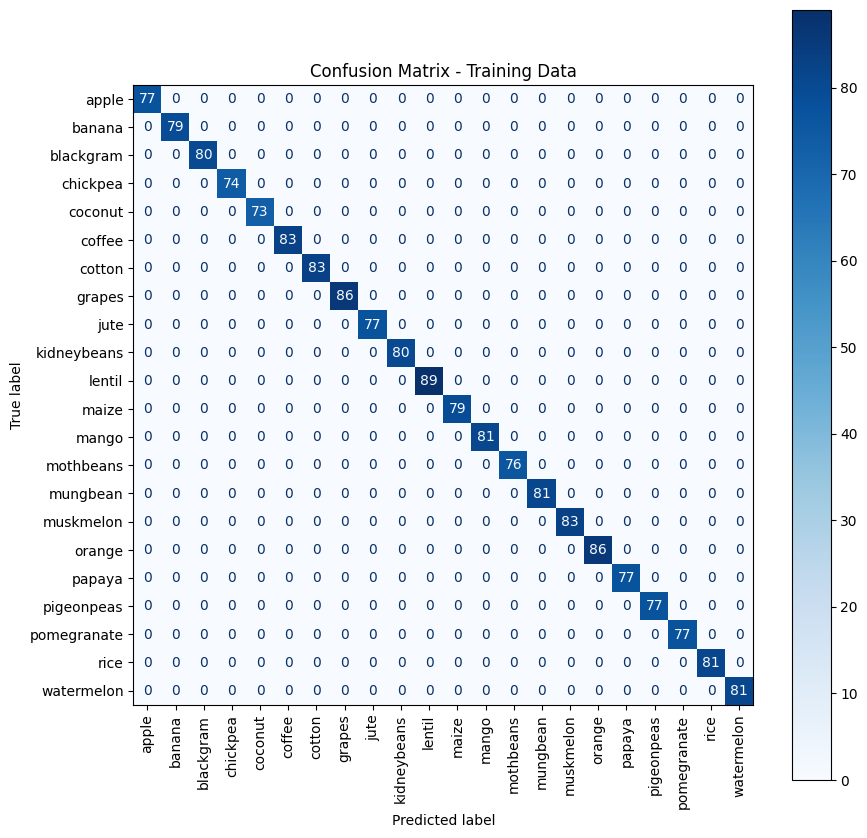

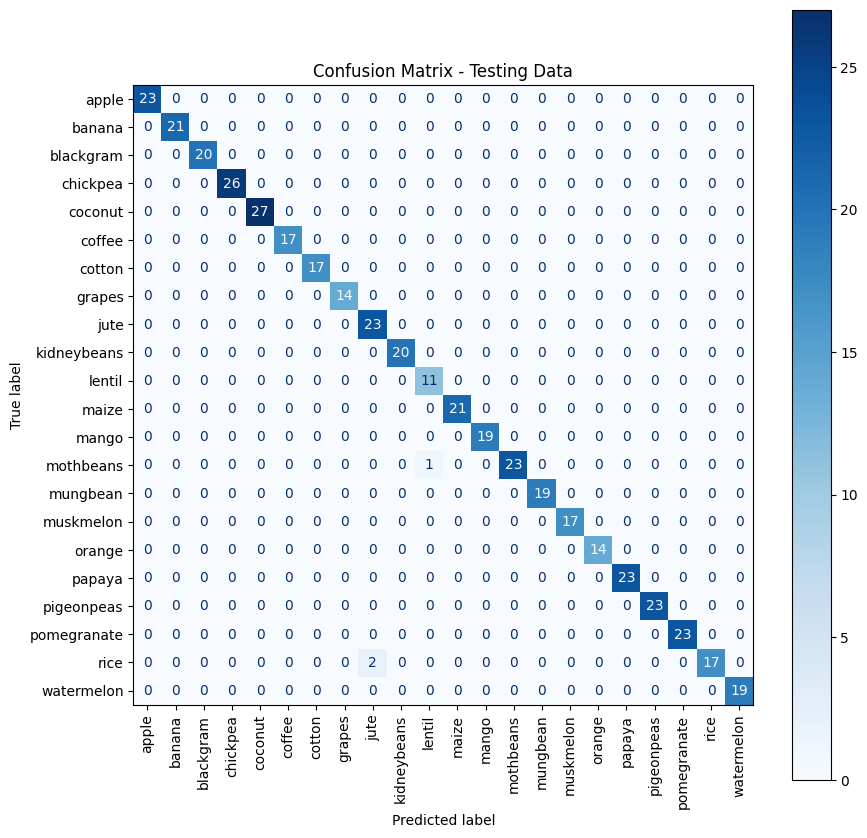

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Visualize performance on training data
y_train_pred = model.predict(X_train)
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(10, 10))
disp_train.plot(ax=ax, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Training Data')
plt.xticks(rotation=90)
plt.show()

# Visualize performance on testing data
y_test_pred = model.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(10, 10))
disp_test.plot(ax=ax, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Testing Data')
plt.xticks(rotation=90)
plt.show()

## Model Performance Metrics
Display key performance metrics for the model on both training and testing data.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Performance on training data
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Data Performance:")
print(f"Accuracy: {train_accuracy}")
print("Classification Report:")
print(classification_report(y_train, y_train_pred))

# Performance on testing data
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("\nTesting Data Performance:")
print(f"Accuracy: {test_accuracy}")
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Training Data Performance:
Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        77
      banana       1.00      1.00      1.00        79
   blackgram       1.00      1.00      1.00        80
    chickpea       1.00      1.00      1.00        74
     coconut       1.00      1.00      1.00        73
      coffee       1.00      1.00      1.00        83
      cotton       1.00      1.00      1.00        83
      grapes       1.00      1.00      1.00        86
        jute       1.00      1.00      1.00        77
 kidneybeans       1.00      1.00      1.00        80
      lentil       1.00      1.00      1.00        89
       maize       1.00      1.00      1.00        79
       mango       1.00      1.00      1.00        81
   mothbeans       1.00      1.00      1.00        76
    mungbean       1.00      1.00      1.00        81
   muskmelon       1.00      1.00      1.00        83
      orange     

##Predictive Modelling

### Predicting Conditions for the Majority Crop Type using Random Forest Classifier

The majority crop type in the dataset is: rice

Accuracy for predicting 'rice' conditions: 0.9955

Classification Report for predicting 'rice' conditions:
              precision    recall  f1-score   support

 Other Crops       1.00      1.00      1.00       420
        rice       1.00      0.90      0.95        20

    accuracy                           1.00       440
   macro avg       1.00      0.95      0.97       440
weighted avg       1.00      1.00      1.00       440



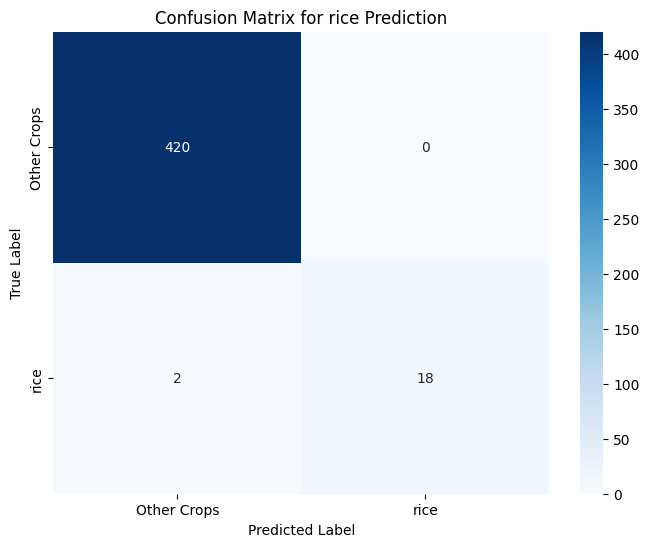

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Re-load the crop recommendation dataset to ensure 'df' is correctly defined
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/crop recommendation dataset.csv")

# Identify the majority crop type
majority_crop = df['label'].value_counts().idxmax()
print(f"The majority crop type in the dataset is: {majority_crop}")

# Create a new target variable: 1 if it's the majority crop, 0 otherwise
df['is_majority_crop'] = (df['label'] == majority_crop).astype(int)

# Define features (X) and the new target (y)
X_majority = df.drop(['label', 'is_majority_crop'], axis=1)
y_majority = df['is_majority_crop']

# Split the data into training and testing sets
X_train_majority, X_test_majority, y_train_majority, y_test_majority = train_test_split(X_majority, y_majority, test_size=0.2, random_state=42, stratify=y_majority)

# Initialize and train a RandomForestClassifier
rf_majority_model = RandomForestClassifier(random_state=42)
rf_majority_model.fit(X_train_majority, y_train_majority)

# Make predictions
y_pred_majority = rf_majority_model.predict(X_test_majority)

# Evaluate the model
accuracy_majority = accuracy_score(y_test_majority, y_pred_majority)
print(f"\nAccuracy for predicting '{majority_crop}' conditions: {accuracy_majority:.4f}")
print(f"\nClassification Report for predicting '{majority_crop}' conditions:")
print(classification_report(y_test_majority, y_pred_majority, target_names=['Other Crops', majority_crop]))

# Display Confusion Matrix
cm_majority = confusion_matrix(y_test_majority, y_pred_majority)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_majority, annot=True, fmt='d', cmap='Blues', xticklabels=['Other Crops', majority_crop], yticklabels=['Other Crops', majority_crop])
plt.title(f'Confusion Matrix for {majority_crop} Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Box Plots to Compare Conditions for 'Rice' vs. 'Other Crops'

/tmp/ipykernel_850/2347605246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_majority_crop', y=feature, data=df, palette='viridis')
/tmp/ipykernel_850/2347605246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_majority_crop', y=feature, data=df, palette='viridis')
/tmp/ipykernel_850/2347605246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_majority_crop', y=feature, data=df, palette='viridis')
/tmp/ipykernel_850/2347605246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

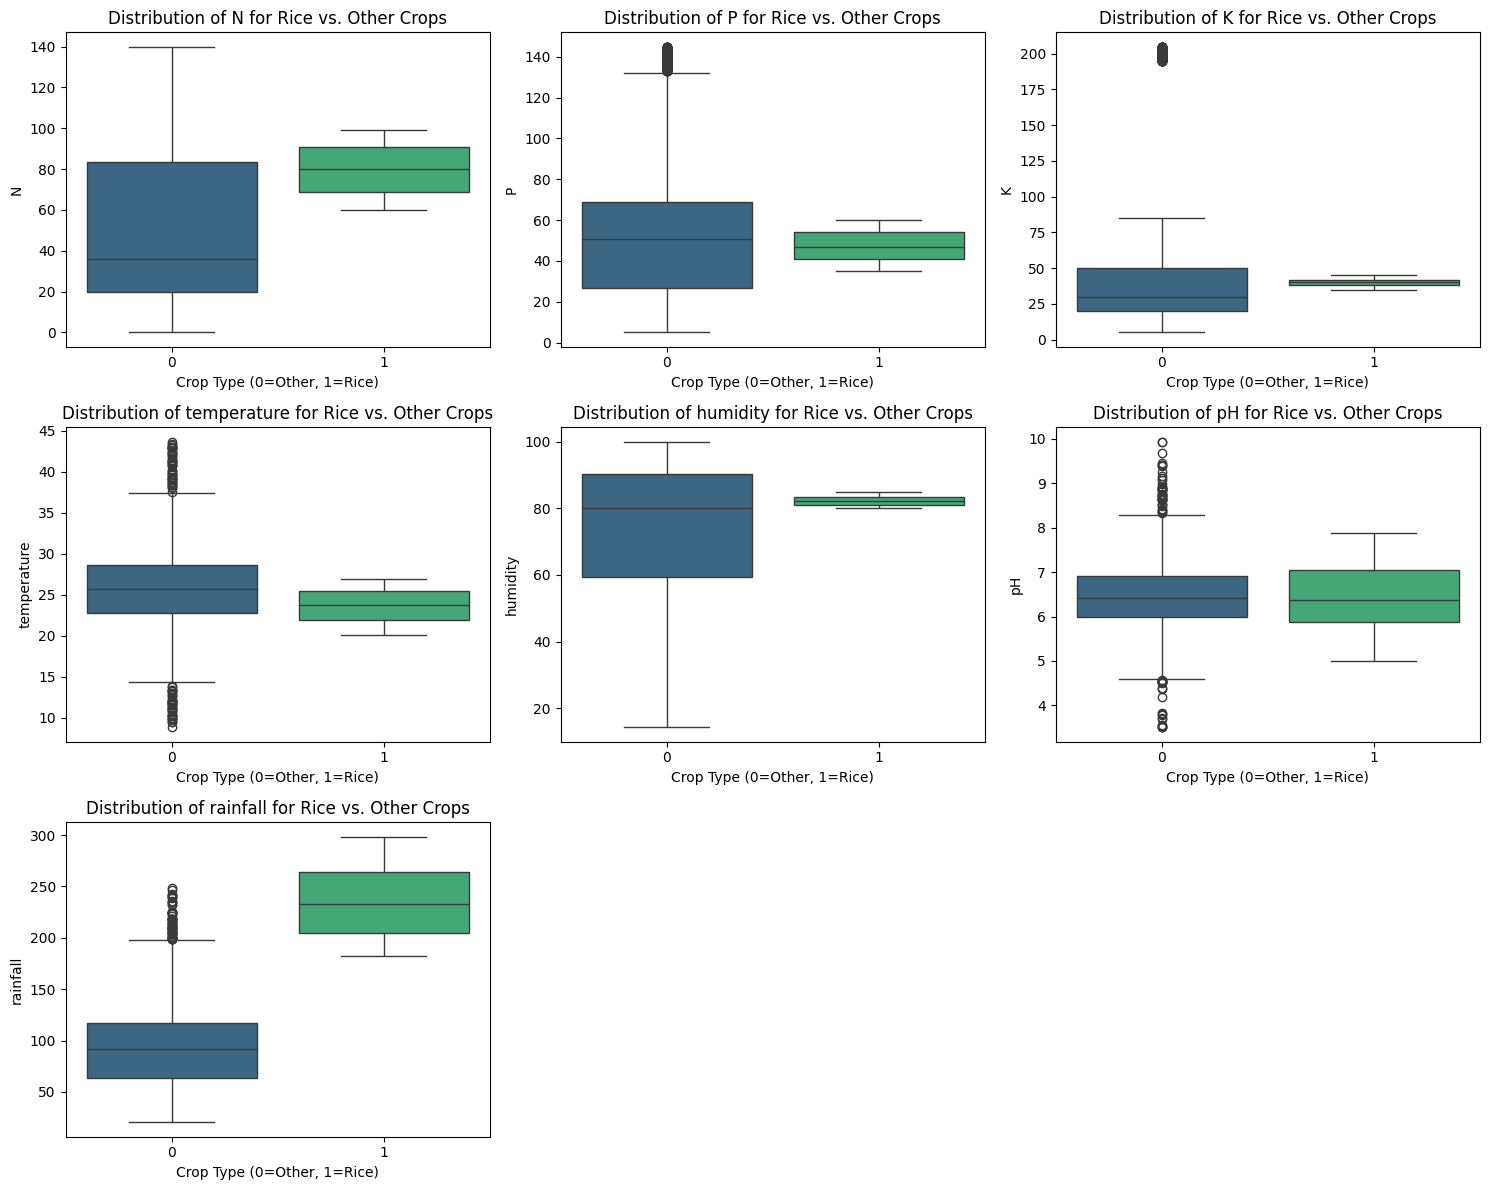

In [ ]:
numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'pH', 'rainfall']

plt.figure(figsize=(15, 12))

for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.boxplot(x='is_majority_crop', y=feature, data=df, palette='viridis')
    plt.title(f'Distribution of {feature} for Rice vs. Other Crops')
    plt.xlabel('Crop Type (0=Other, 1=Rice)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

##**PRINCIPLE COMPONENT ANALYSIS (PCA)**





In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/crop recommendation dataset.csv')

# Separate features and target
features = ['N', 'P', 'K', 'temperature', 'humidity', 'pH', 'rainfall']
X = df[features]
y = df['label']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df['label'] = y

# Visualize the explained variance
plt.figure(figsize=(10, 6))
sns.barplot(x=[f'PC{i+1}' for i in range(pca.n_components_)], y=pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component')
plt.savefig('explained_variance_ratio.png')
plt.close()

# Visualize the PCA components
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='label',
    data=pca_df,
    palette=sns.color_palette("hsv", n_colors=len(df['label'].unique())),
    s=70,
    alpha=0.7
)
plt.title('PCA of Crop Recommendation Dataset', fontsize=18)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pca_scatter_plot.png')
plt.close()

# Analyze the component loadings to find the most important variables
loadings_df = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])
loadings_df.to_csv('pca_loadings.csv')

print("Principal Component Loadings:")
print(loadings_df)

# Find the most important variables for the first two principal components
important_vars_pc1 = loadings_df.loc['PC1'].abs().sort_values(ascending=False)
important_vars_pc2 = loadings_df.loc['PC2'].abs().sort_values(ascending=False)

# Find the overall top variables based on their contribution to the first two PCs
top_variables = pd.concat([important_vars_pc1, important_vars_pc2], axis=1).max(axis=1).sort_values(ascending=False)

print("\nOverall top variables based on PC1 and PC2:")
print(top_variables)

Principal Component Loadings:
            N         P         K  temperature  humidity        pH  rainfall
PC1 -0.302191  0.643787  0.622607    -0.212428 -0.068483 -0.226943 -0.072532
PC2  0.334107  0.034358  0.283829     0.359487  0.737917 -0.220657  0.290158
PC3 -0.112045 -0.109939 -0.163173    -0.248228 -0.213599 -0.548520  0.735267
PC4 -0.541651 -0.046293 -0.154867     0.690826 -0.067171 -0.395700 -0.205318
PC5 -0.507785  0.082331  0.033425     0.154865  0.128871  0.651881  0.518382
PC6 -0.482904 -0.376847 -0.028967    -0.500418  0.547871 -0.125712 -0.239930
PC7 -0.008473 -0.649104  0.692268     0.111282 -0.289624  0.040028  0.038577

Overall top variables based on PC1 and PC2:
humidity       0.737917
P              0.643787
K              0.622607
temperature    0.359487
N              0.334107
rainfall       0.290158
pH             0.226943
dtype: float64


In [ ]:
# Visualize the explained variance
plt.figure(figsize=(10, 6))
sns.barplot(x=[f'PC{i+1}' for i in range(pca.n_components_)], y=pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component')
plt.savefig('explained_variance_ratio.png')
plt.close()

# Visualize the PCA components
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='label',
    data=pca_df,
    palette=sns.color_palette("hsv", n_colors=len(df['label'].unique())),
    s=70,
    alpha=0.7
)
plt.title('PCA of Crop Recommendation Dataset', fontsize=18)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pca_scatter_plot.png')
plt.close()

# Analyze the component loadings to find the most important variables
loadings_df = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])

print("Principal Component Loadings:")
print(loadings_df)

# Find the most important variables for the first two principal components
important_vars_pc1 = loadings_df.loc['PC1'].abs().sort_values(ascending=False)
important_vars_pc2 = loadings_df.loc['PC2'].abs().sort_values(ascending=False)

print("\nTop variables for PC1:")
print(important_vars_pc1)

print("\nTop variables for PC2:")
print(important_vars_pc2)

# Find the overall top variables based on their contribution to the first two PCs
top_variables = pd.concat([important_vars_pc1, important_vars_pc2], axis=1).max(axis=1).sort_values(ascending=False)

print("\nOverall top variables based on PC1 and PC2:")
print(top_variables)

# Write the loadings to a CSV file
loadings_df.to_csv('pca_loadings.csv')


Principal Component Loadings:
            N         P         K  temperature  humidity        pH  rainfall
PC1 -0.302191  0.643787  0.622607    -0.212428 -0.068483 -0.226943 -0.072532
PC2  0.334107  0.034358  0.283829     0.359487  0.737917 -0.220657  0.290158
PC3 -0.112045 -0.109939 -0.163173    -0.248228 -0.213599 -0.548520  0.735267
PC4 -0.541651 -0.046293 -0.154867     0.690826 -0.067171 -0.395700 -0.205318
PC5 -0.507785  0.082331  0.033425     0.154865  0.128871  0.651881  0.518382
PC6 -0.482904 -0.376847 -0.028967    -0.500418  0.547871 -0.125712 -0.239930
PC7 -0.008473 -0.649104  0.692268     0.111282 -0.289624  0.040028  0.038577

Top variables for PC1:
P              0.643787
K              0.622607
N              0.302191
pH             0.226943
temperature    0.212428
rainfall       0.072532
humidity       0.068483
Name: PC1, dtype: float64

Top variables for PC2:
humidity       0.737917
temperature    0.359487
N              0.334107
rainfall       0.290158
K              0

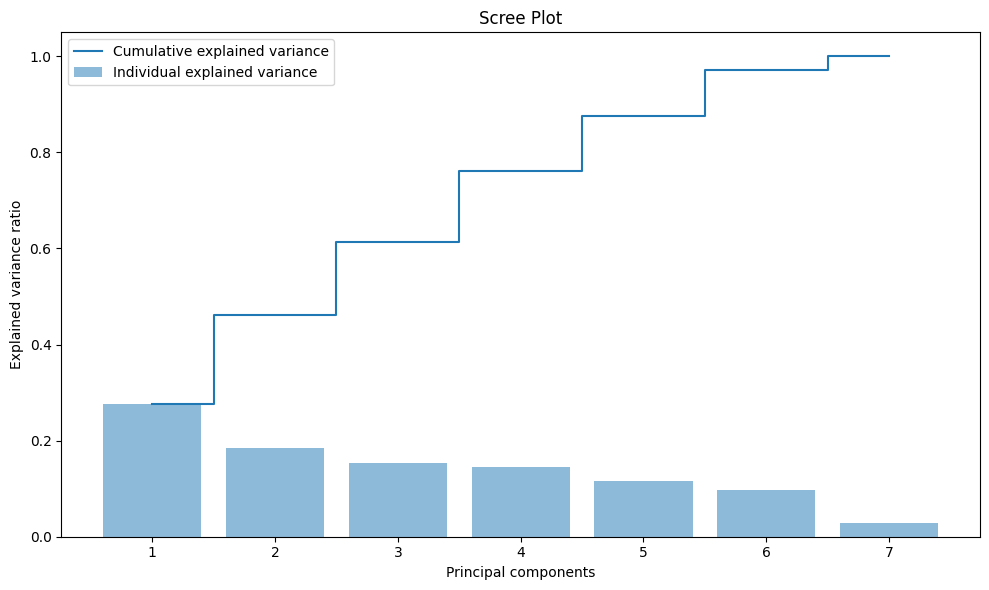

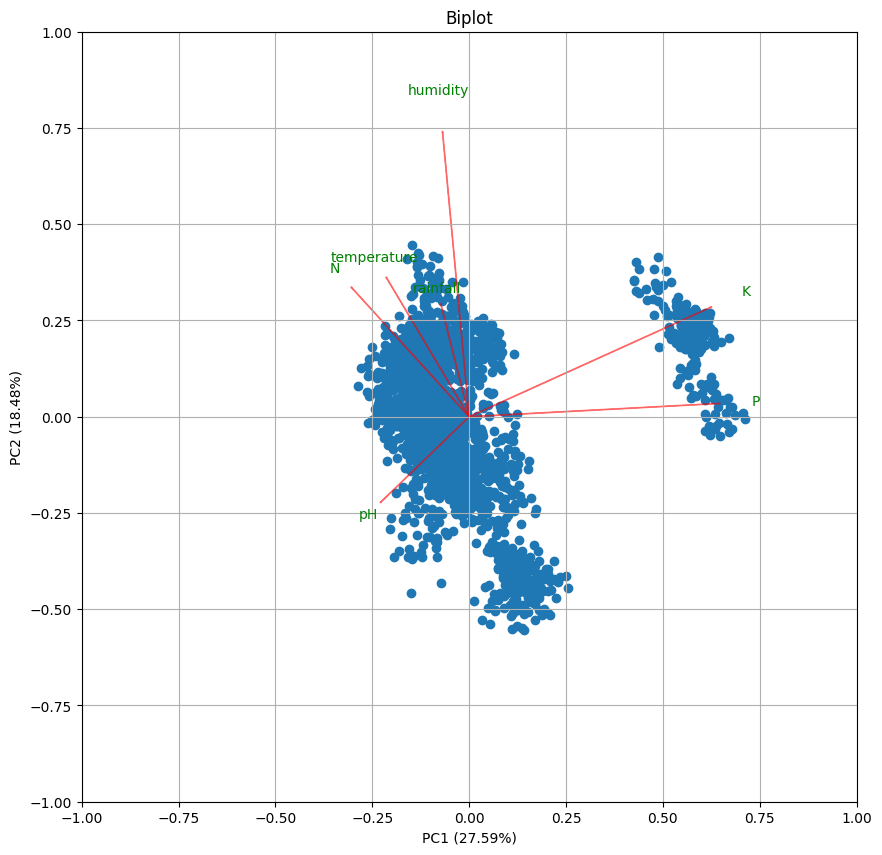

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/crop recommendation dataset.csv')

# Drop the 'label' column as PCA is performed on numerical features
numerical_features = df.drop('label', axis=1)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_features)

# Apply PCA
pca = PCA()
principal_components = pca.fit_transform(scaled_data)

# Scree Plot to visualize the explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.title('Scree Plot')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('scree_plot.png')
plt.show()

# Biplot for identifying important variables
def biplot(score, coeff, labels=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    plt.figure(figsize=(10, 10))
    plt.scatter(xs * scalex, ys * scaley)
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color='r', alpha=0.5)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color='g', ha='center', va='center')
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.xlabel(f"PC1 ({round(pca.explained_variance_ratio_[0]*100, 2)}%)")
    plt.ylabel(f"PC2 ({round(pca.explained_variance_ratio_[1]*100, 2)}%)")
    plt.grid()
    plt.title('Biplot')
    plt.savefig('biplot.png')
    plt.show()

# Create the biplot
biplot(principal_components[:,0:2], np.transpose(pca.components_[0:2, :]), labels=numerical_features.columns)

## **K-MEANS CLUSTERING**

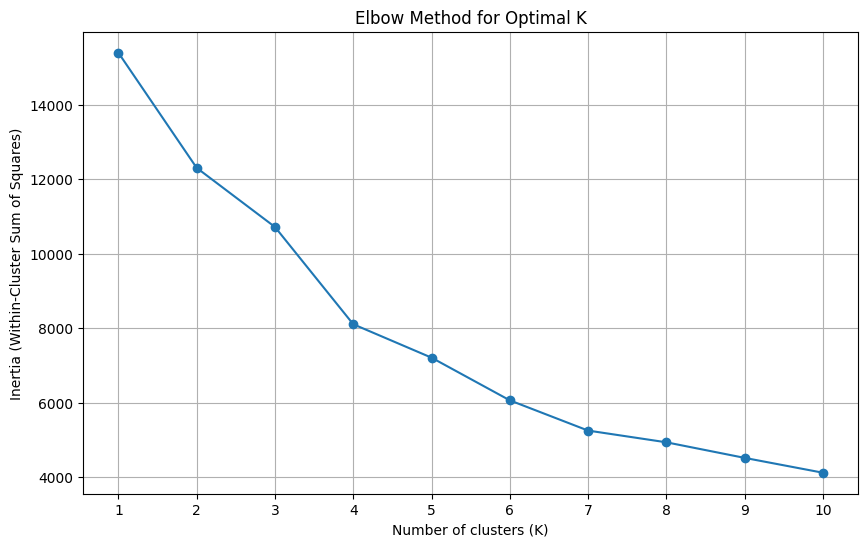

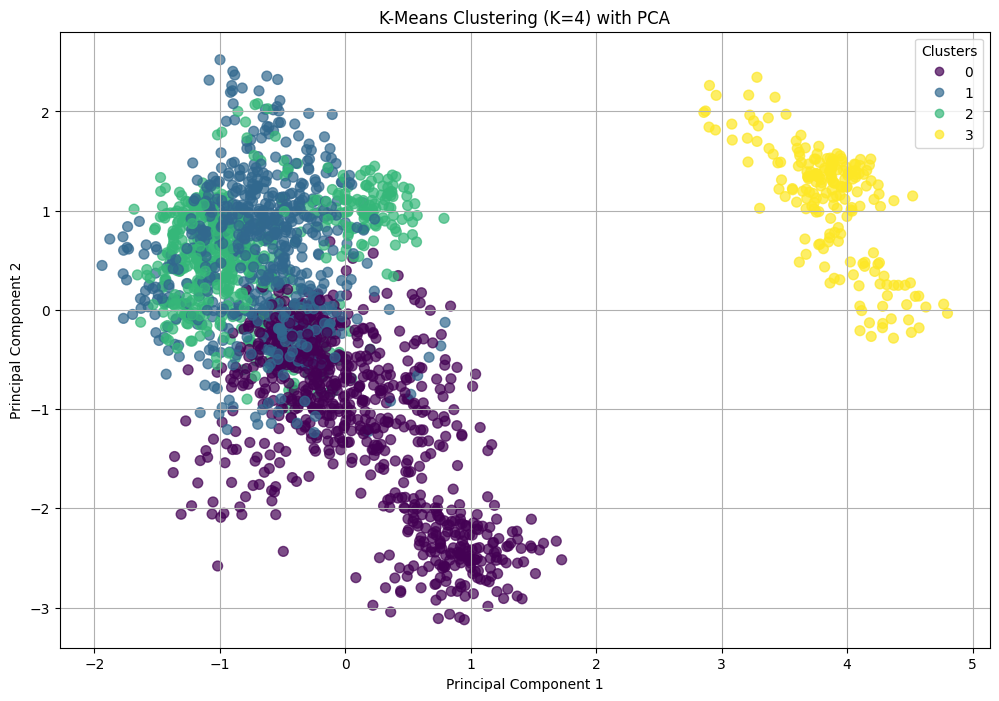

Cluster Centers (in original scale):
           N           P           K  temperature   humidity        pH  \
0  26.089084   57.520703   28.639900    26.042699  50.333654  6.539446   
1  47.726537   32.592233   33.372168    25.137362  85.602737  6.547173   
2  96.629060   42.285470   38.423932    26.353442  80.035282  6.460179   
3  21.990000  133.375000  200.000000    23.240259  87.104305  5.977800   

     rainfall  
0   79.166308  
1  165.346991  
2   75.407510  
3   91.133304  


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np



# Separate features from the categorical 'label' column for clustering
features = df.drop('label', axis=1)

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# --- Elbow Method to find the optimal number of clusters ---
inertia = []
range_of_k = range(1, 11)
for k in range_of_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_of_k, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(range_of_k)
plt.grid(True)
plt.savefig('elbow_method.png')
plt.show()

# --- Perform K-Means clustering with the optimal number of clusters (e.g., K=4 from the elbow plot) ---
# Assuming the elbow method suggests an optimal K of 4.
# The user can visually inspect the plot to choose a different K if needed.
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans_model.fit_predict(scaled_features)

# Add the cluster labels to the original dataframe for analysis
df['cluster_label'] = clusters

# --- Visualize the clusters using PCA for dimensionality reduction ---
# Reduce the features to 2 principal components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['cluster_label'] = clusters

# Plot the clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['cluster_label'], cmap='viridis', s=50, alpha=0.7)
plt.title(f'K-Means Clustering (K={optimal_k}) with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title='Clusters')
plt.grid(True)
plt.savefig('k_means_pca_clusters.png')
plt.show()

# Print the final cluster centers (in the original feature space)
cluster_centers = scaler.inverse_transform(kmeans_model.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=features.columns)
print("Cluster Centers (in original scale):")
print(cluster_centers_df)

## **DECISION TREE CLASSIFIER**

Accuracy of the Decision Tree Classifier: 0.99

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       0.96      1.00      0.98        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      oran

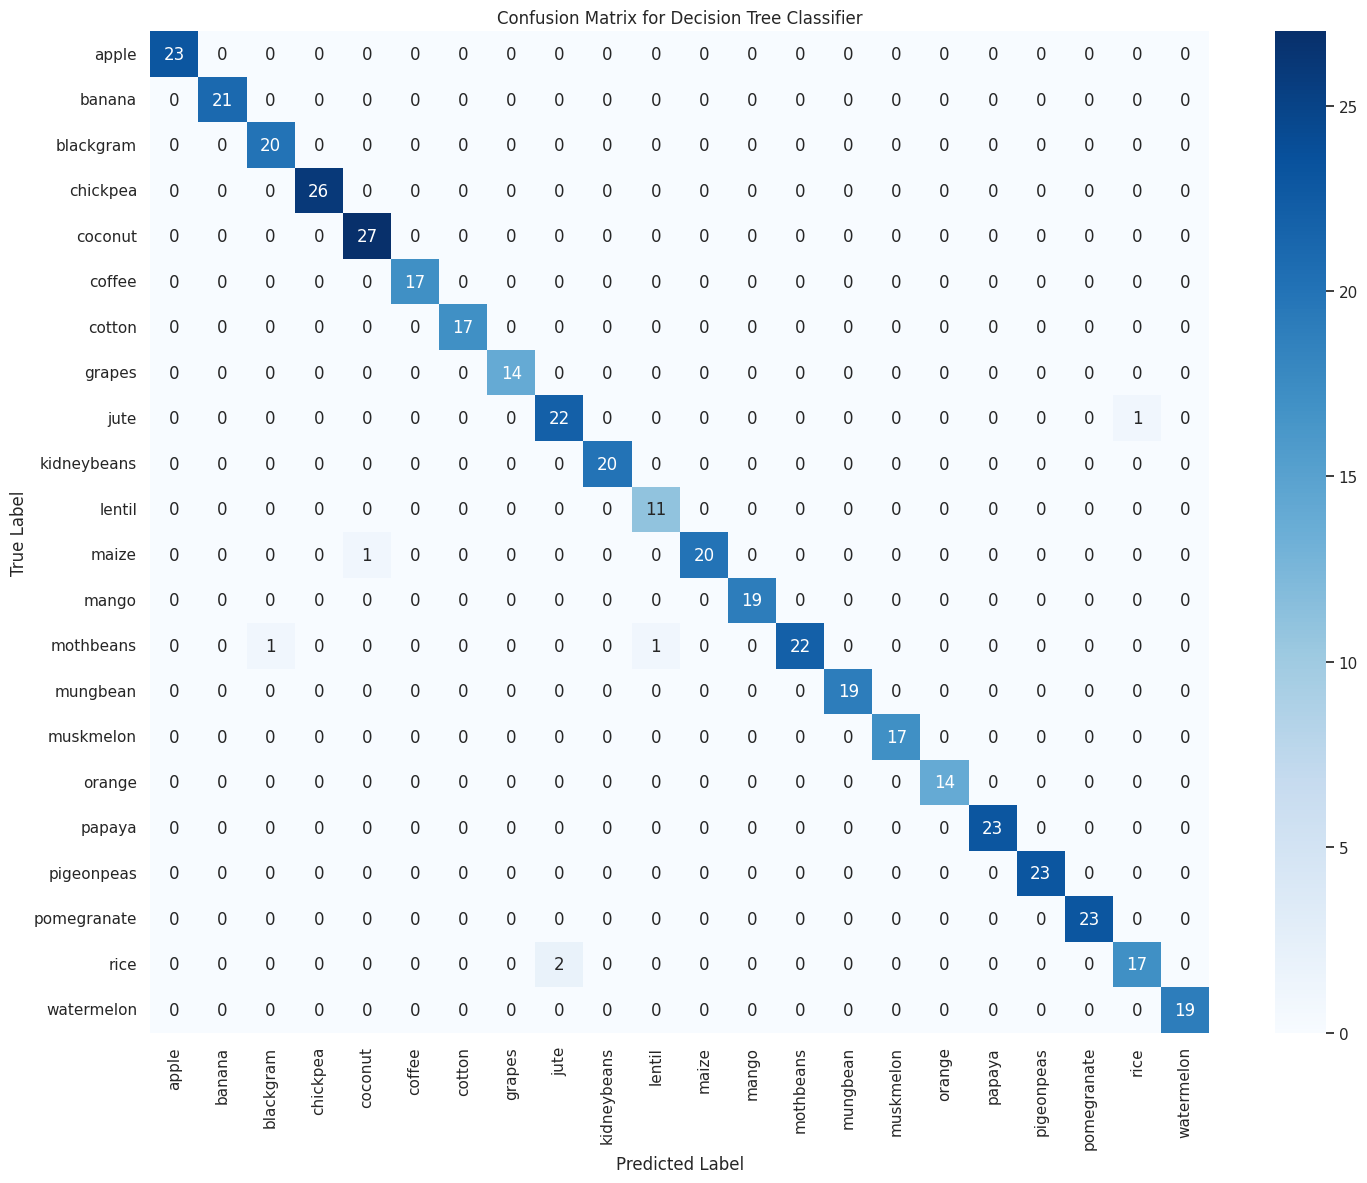

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Separate features and target variable
X = df.drop('label', axis=1)
y = df['label']

# Encode the categorical labels into numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = decision_tree_model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Decision Tree Classifier: {accuracy:.2f}")

# Display a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Display a confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

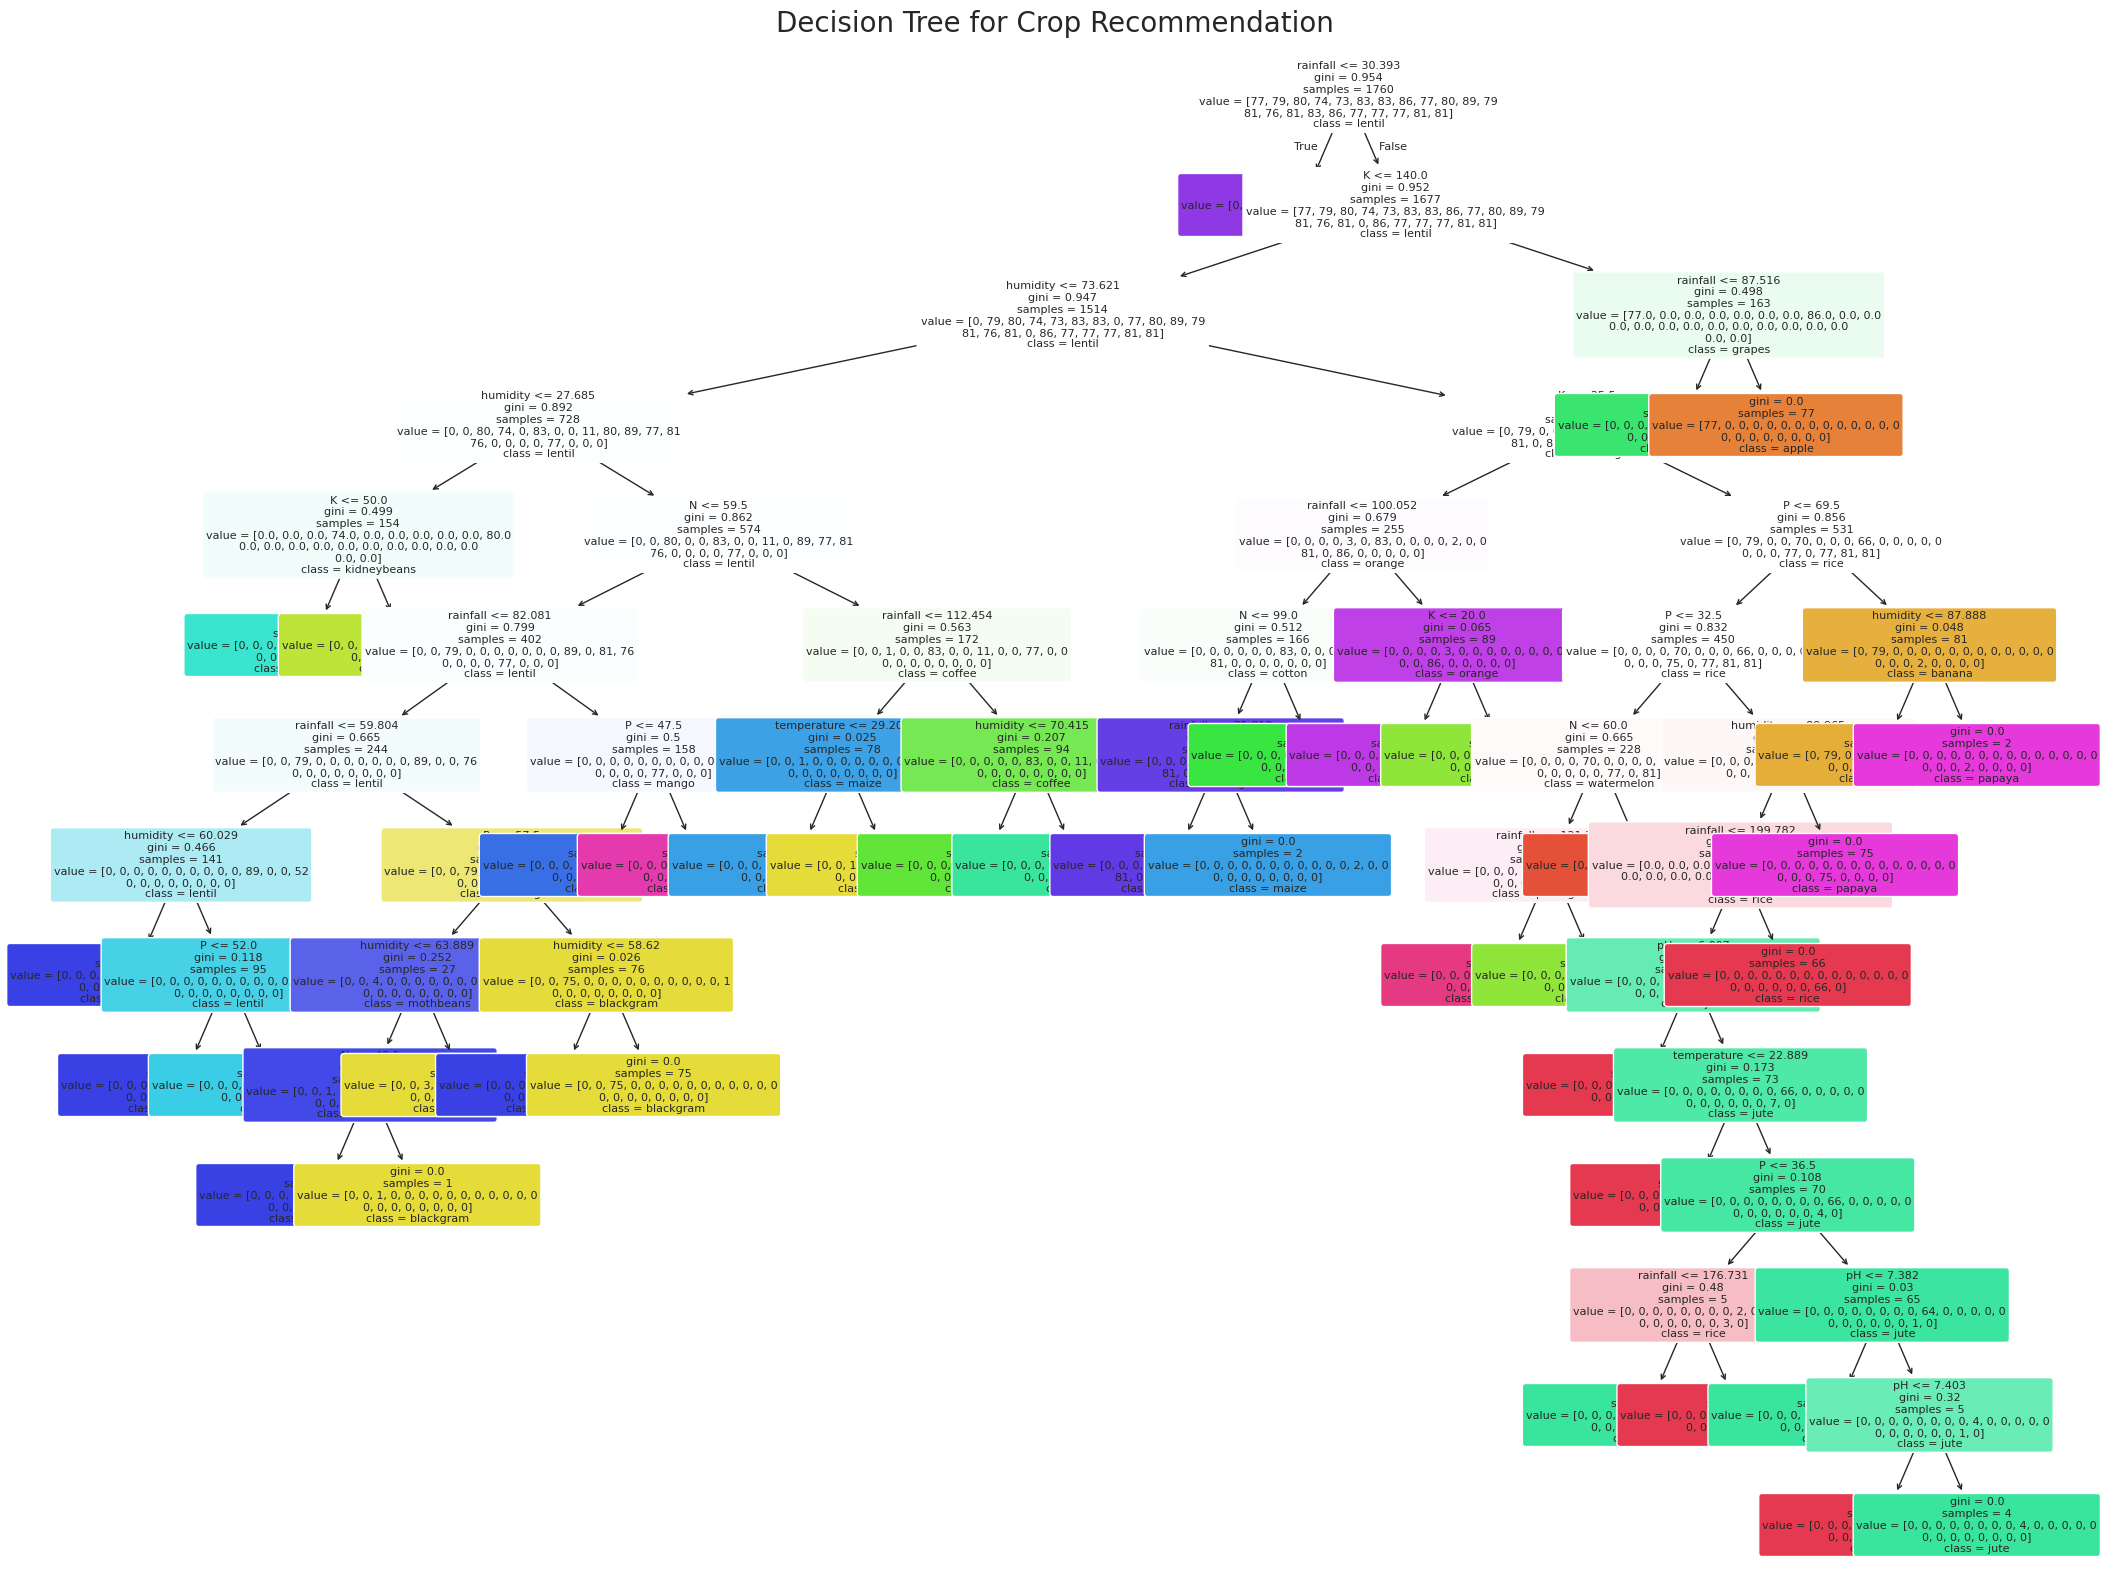


Feature Importances:
             importance
rainfall       0.351099
humidity       0.187216
P              0.162547
K              0.145078
N              0.141650
pH             0.008189
temperature    0.004220


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Separate features and target variable
X = df.drop('label', axis=1)
y = df['label']

# Encode the categorical labels into numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Get feature names and class names for the plot
feature_names = X.columns.tolist()
class_names = label_encoder.classes_.tolist()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# --- Visualize the Decision Tree ---
plt.figure(figsize=(25, 20))
plot_tree(decision_tree_model,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=8,
          impurity=True)
plt.title('Decision Tree for Crop Recommendation', fontsize=20)
plt.savefig('decision_tree_visualization.png', dpi=300)
plt.show()

# --- Analysis of Feature Importance ---
# The most important features are those that appear at the top of the tree,
# and have a large impact on the Gini impurity.
# We can also get a numerical value for feature importance.
feature_importances = pd.DataFrame(decision_tree_model.feature_importances_,
                                   index=feature_names,
                                   columns=['importance']).sort_values('importance', ascending=False)
print("\nFeature Importances:")
print(feature_importances)